# Paper Visualizations

In [80]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from pathlib import Path
import matplotlib.image as mpimg

## Example Image Data

In [81]:
def add_silhouette(
    ax,
    image,
    position=(0.55, 0.10),
    zoom=0.12,
    alpha=0.4,
):
    
    img = OffsetImage(
        image,
        zoom=zoom,
        alpha=alpha
    )

    box = AnnotationBbox(
        img,
        position,
        xycoords="axes fraction",
        frameon=False,
        zorder=0,
    )

    ax.add_artist(box)



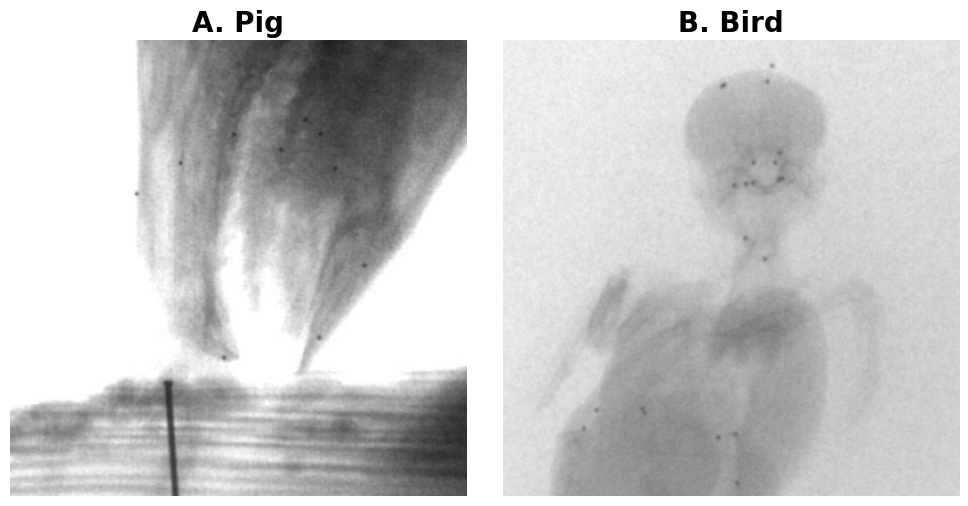

In [63]:


pig_data = mpimg.imread(
    r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Pig_T4/test/Cam1/20061229susDFc01S0004-00.01118.jpg"
)

bird_data = mpimg.imread(
    r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/DB_T15/test/Cam1/Cam1_Img002417.jpg"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# A: Pig
axes[0].imshow(pig_data)
axes[0].set_title("A. Pig",  fontsize=20, fontweight="bold")
axes[0].axis("off")
axes[0].set_xlim(400, 800)
axes[0].set_ylim(800, 400)
# B: Bird
axes[1].imshow(bird_data, cmap="gray")
axes[1].set_title("B. Bird", fontsize=20, fontweight="bold")
axes[1].axis("off")
axes[1].set_xlim(200, 500)
axes[1].set_ylim(450, 150)
plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/BirdPigRaw_Figure_zoomed.png", dpi=300, bbox_inches="tight", )
plt.show()


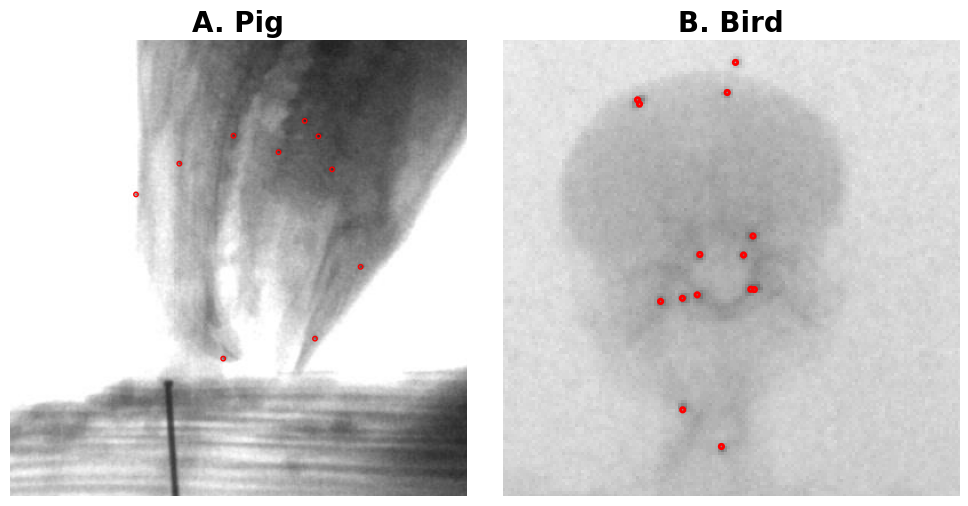

In [113]:


pig_data = mpimg.imread(
    r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Pig_T4/test/Cam1/20061229susDFc01S0004-00.01118.jpg"
)

bird_data = mpimg.imread(
    r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/DB_T15/test/Cam1/Cam1_Img002417.jpg"
)
import numpy as np
import pandas as pd


def _extract_camera_predictions(row: pd.Series, camera: str):
    """
    Extract predicted coordinates for a single camera from a dataframe row.

    Parameters
    ----------
    row : pd.Series
        One row of the prediction dataframe.

    camera : str
        Camera identifier (e.g. 'cam1' or 'cam2').

    Returns
    -------
    pred_points : ndarray, shape (N, 2)
        Predicted coordinates as [y, x].

    bodyparts : list[str]
        Matching bodypart names including camera suffix.
        Example:
            ['nose_cam1', 'tail_cam1']
    """

    pred_points = []
    bodyparts = []

    x_suffix = f"_{camera}_X"

    for col in row.index:

        if not col.endswith(x_suffix):
            continue

        prefix = col[:-2]  # remove "_X"

        x = row[f"{prefix}_X"]
        y = row[f"{prefix}_Y"]

        if np.isnan(x) or np.isnan(y):
            continue

        pred_points.append([y, x])
        bodyparts.append(prefix)

    return np.asarray(pred_points), bodyparts

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

data = pd.read_csv(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/DB_T15/test/LabeledBodyPartsCoordinates.csv")
rowed = data.iloc[0]

img = plt.imread(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/DB_T15/test/Cam1/Cam1_Img002417.jpg")
image = np.asarray(img, dtype=np.float64)


axes[1].imshow(image, cmap="gray")

for col in data.columns: 

    if col.endswith("_X"):
        if "cam1" in col:

            bp = col[:-2]

            x_old = rowed[f"{bp}_X"]
            y_old = rowed[f"{bp}_Y"]

            axes[1].scatter(x_old, y_old,
                        facecolors='none',
                        edgecolors='red',
                        linewidths=2,
                    s=10,
                    label="original")

axes[1].set_title("B. Bird",  fontsize=20, fontweight="bold")
axes[1].axis("off")
axes[1].set_xlim(300, 450)
axes[1].set_ylim(310, 160)



pig_data = pd.read_csv(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Pig_T4/test/LabeledBodyPartsCoordinates.csv")
pig_data.columns = pig_data.columns.str.replace(" ", "_")

rowed = pig_data.iloc[-3]

pig_image = plt.imread(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Pig_T4/test/Cam1/20061229susDFc01S0004-00.01113.jpg")
pig_img = np.asarray(pig_image, dtype=np.float64)

axes[0].imshow(pig_image)

for col in pig_data.columns: 

    if col.endswith("_X"):
        if "cam1" in col:
            bp = col[:-2]

            x_old = rowed[f"{bp}_X"]
            y_old = rowed[f"{bp}_Y"]

            axes[0].scatter(x_old, y_old,
                        facecolors='none',
                        edgecolors='red',
                        linewidths=1,
                    s=10,
                    label="original")

axes[0].set_title("A. Pig", fontsize=20, fontweight="bold")
axes[0].axis("off")
axes[0].set_xlim(400, 800)
axes[0].set_ylim(800, 400)
plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/BirdPigBlobDetect_Figure_truth.png", dpi=300, bbox_inches="tight", )
plt.show()

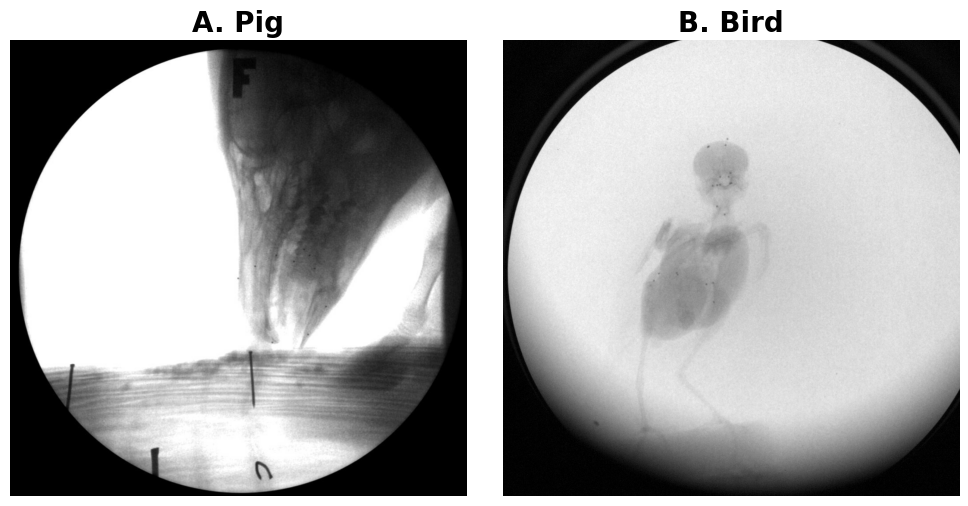

In [115]:

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# A: Pig
axes[0].imshow(pig_image)
axes[0].set_title("A. Pig",  fontsize=20, fontweight="bold")
axes[0].axis("off")

# B: Bird
axes[1].imshow(bird_data, cmap="gray")
axes[1].set_title("B. Bird", fontsize=20, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/BirdPigRaw_Figure.png", dpi=300, bbox_inches="tight", )
plt.show()

In [66]:
import shutil
import ffmpeg
print(shutil.which("ffmpeg"))

/home/kelsey/anaconda3/envs/DEEPLABCUT/bin/ffmpeg


In [67]:
pip install ffmpeg

Note: you may need to restart the kernel to use updated packages.


In [68]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.animation import PillowWriter


# ============================================================
# PATHS
# ============================================================

DATA_ROOT = Path(
    "/home/kelsey/Documents/TylerMachineLearning/"
    "Testing/DeepLabCutExperiments/Data"
)

OUTPUT = Path(
    "/home/kelsey/Documents/TylerMachineLearning/"
    "Testing/DeepLabCutExperiments/Figures/"
    "BirdPigRaw_Cam1_Cam2.mp4"
)

PIG_TRIAL = "Pig_T4"
BIRD_TRIAL = "DB_T15"


# ============================================================
# GET IMAGE FILES
# ============================================================

def get_images(directory):

    extensions = [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.JPG",
        "*.JPEG",
        "*.PNG",
    ]

    images = []

    for ext in extensions:
        images.extend(directory.glob(ext))

    # Important: sort consistently
    return sorted(images)


pig_cam1 = get_images(
    DATA_ROOT / PIG_TRIAL / "test" / "Cam1"
)

pig_cam2 = get_images(
    DATA_ROOT / PIG_TRIAL / "test" / "Cam2"
)

bird_cam1 = get_images(
    DATA_ROOT / BIRD_TRIAL / "test" / "Cam1"
)

bird_cam2 = get_images(
    DATA_ROOT / BIRD_TRIAL / "test" / "Cam2"
)


# ============================================================
# CHECK
# ============================================================

print("Number of frames:")
print(f"Pig Cam 1:  {len(pig_cam1)}")
print(f"Pig Cam 2:  {len(pig_cam2)}")
print(f"Bird Cam 1: {len(bird_cam1)}")
print(f"Bird Cam 2: {len(bird_cam2)}")


if not pig_cam1:
    raise RuntimeError("No Pig Cam1 images found")

if not pig_cam2:
    raise RuntimeError("No Pig Cam2 images found")

if not bird_cam1:
    raise RuntimeError("No Bird Cam1 images found")

if not bird_cam2:
    raise RuntimeError("No Bird Cam2 images found")


# ============================================================
# NUMBER OF FRAMES
# ============================================================

n_frames = min(
    len(pig_cam1),
    len(pig_cam2),
    len(bird_cam1),
    len(bird_cam2),
)

print(f"\nUsing {n_frames} synchronized frames")


# ============================================================
# INITIAL FRAME
# ============================================================

pig1_data = mpimg.imread(pig_cam1[0])
pig2_data = mpimg.imread(pig_cam2[0])

bird1_data = mpimg.imread(bird_cam1[0])
bird2_data = mpimg.imread(bird_cam2[0])


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)


# ------------------------------------------------------------
# Pig Cam 1
# ------------------------------------------------------------

pig1_im = axes[0, 0].imshow(pig1_data)

axes[0, 0].set_title(
    "A. Pig — Cam 1",
    fontsize=18,
    fontweight="bold"
)

axes[0, 0].axis("off")


# ------------------------------------------------------------
# Pig Cam 2
# ------------------------------------------------------------

pig2_im = axes[0, 1].imshow(pig2_data)

axes[0, 1].set_title(
    "B. Pig — Cam 2",
    fontsize=18,
    fontweight="bold"
)

axes[0, 1].axis("off")


# ------------------------------------------------------------
# Bird Cam 1
# ------------------------------------------------------------

bird1_im = axes[1, 0].imshow(
    bird1_data,
    cmap="gray"
)

axes[1, 0].set_title(
    "C. Bird — Cam 1",
    fontsize=18,
    fontweight="bold"
)

axes[1, 0].axis("off")


# ------------------------------------------------------------
# Bird Cam 2
# ------------------------------------------------------------

bird2_im = axes[1, 1].imshow(
    bird2_data,
    cmap="gray"
)

axes[1, 1].set_title(
    "D. Bird — Cam 2",
    fontsize=18,
    fontweight="bold"
)

axes[1, 1].axis("off")


plt.tight_layout()


# ============================================================
# UPDATE FUNCTION
# ============================================================

def update(frame):

    # Load current frame from each camera
    pig1_frame = mpimg.imread(
        pig_cam1[frame]
    )

    pig2_frame = mpimg.imread(
        pig_cam2[frame]
    )

    bird1_frame = mpimg.imread(
        bird_cam1[frame]
    )

    bird2_frame = mpimg.imread(
        bird_cam2[frame]
    )

    # Update images
    pig1_im.set_data(pig1_frame)
    pig2_im.set_data(pig2_frame)

    bird1_im.set_data(bird1_frame)
    bird2_im.set_data(bird2_frame)

    # Frame counter
    fig.suptitle(
        f"Frame {frame + 1} / {n_frames}",
        fontsize=14
    )

    return (
        pig1_im,
        pig2_im,
        bird1_im,
        bird2_im,
    )


# ============================================================
# CREATE ANIMATION
# ============================================================

ani = FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=40,
    blit=True
)


# ============================================================
# SAVE MP4
# ============================================================

writer = FFMpegWriter(
    fps=25,
    bitrate=5000
)

ani.save(
    OUTPUT,
    writer=writer,
    dpi=200
)

plt.close(fig)

print("\nSaved:")
print(OUTPUT)

Number of frames:
Pig Cam 1:  300
Pig Cam 2:  300
Bird Cam 1: 300
Bird Cam 2: 300

Using 300 synchronized frames

Saved:
/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/BirdPigRaw_Cam1_Cam2.mp4


## Blob Detection Visualization

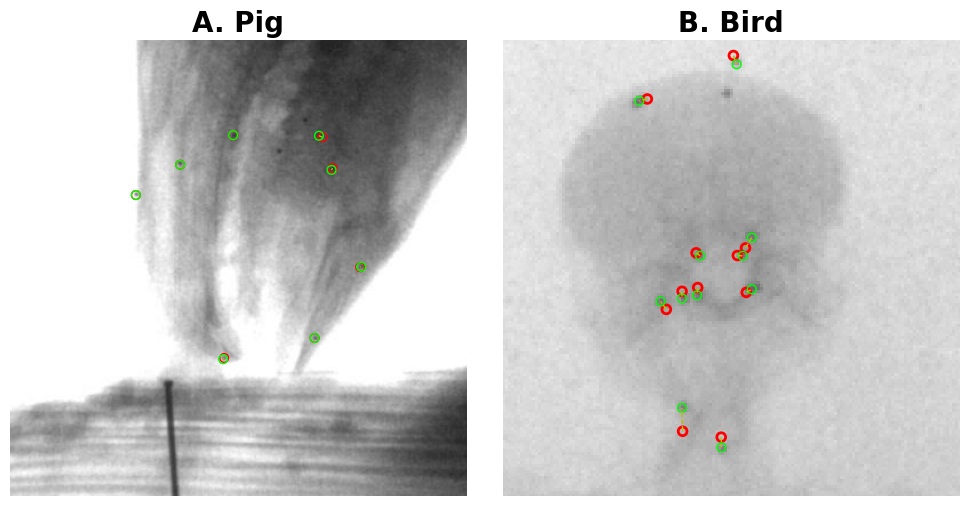

In [189]:
import numpy as np
import pandas as pd

from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from skimage.feature import blob_dog


def fft_zero_pad_superres(image, scale=2):

    rows, cols = image.shape

    new_rows = rows * scale
    new_cols = cols * scale

    # Forward FFT
    F = np.fft.fftshift(np.fft.fft2(image))

    # Zero-padded spectrum
    F_pad = np.zeros((new_rows, new_cols), dtype=complex)

    r0 = (new_rows - rows) // 2
    c0 = (new_cols - cols) // 2

    F_pad[r0:r0+rows, c0:c0+cols] = F

    # Inverse FFT
    upsampled = np.fft.ifft2(np.fft.ifftshift(F_pad))

    # Energy correction
    upsampled *= scale**2

    return np.real(upsampled)

def _correct_camera_frame(
    image,
    row,
    camera,
    animal = 'Bird',
    background_sigma=20,
    min_sigma=1,
    max_sigma=2,
    sigma_ratio=1.3,
    threshold=0.03,
    overlap=0.5,
    max_match_dist=15,
):
    """
    Correct predictions for a single image using blob detection.

    A one-to-one assignment is performed between predicted points
    and detected blobs using the Hungarian algorithm.

    If a prediction lies outside its assigned blob radius,
    it is moved to the blob center.

    Parameters
    ----------
    image : ndarray
        Single grayscale image.

    row : pd.Series
        Prediction dataframe row corresponding to this frame.

    camera : str
        Camera identifier.

    Returns
    -------
    updates : dict
        Mapping of dataframe column names to corrected values.
    """

    background = gaussian_filter(image, sigma=background_sigma)

    hp = background - image
    hp = (hp - hp.min()) / (hp.max() - hp.min() + 1e-8)
    if animal == 'Pig':
        sigma_ratio = 3
  

    blobs = blob_dog(
        hp,
        min_sigma=min_sigma,
        max_sigma=max_sigma,
        sigma_ratio= float(sigma_ratio),
        threshold=threshold,
        overlap=overlap,
    )

    if len(blobs) == 0:
        return {}

    pred_points, bodyparts = _extract_camera_predictions(row, camera)

    if len(pred_points) == 0:
        return {}

    blob_centers = blobs[:, :2]
    

    D = cdist(pred_points, blob_centers)

    D[D > max_match_dist] = 1e6

    pred_idx, blob_idx = linear_sum_assignment(D)

    valid = D[pred_idx, blob_idx] < max_match_dist

    updates = {}

    for p, b in zip(pred_idx[valid], blob_idx[valid]):
        
        py, px = pred_points[p]
        # by, bx, sigma = blobs[b]
        by, bx, sigma = blobs[b][:3]
        radius = sigma * np.sqrt(2)

        dist = np.hypot(py - by, px - bx)

        if dist > radius:
            py = by
            px = bx

        bp = bodyparts[p]

        updates[f"{bp}_X"] = px
        updates[f"{bp}_Y"] = py

    return updates
def _extract_camera_predictions(row: pd.Series, camera: str):
    """
    Extract predicted coordinates for a single camera from a dataframe row.

    Parameters
    ----------
    row : pd.Series
        One row of the prediction dataframe.

    camera : str
        Camera identifier (e.g. 'cam1' or 'cam2').

    Returns
    -------
    pred_points : ndarray, shape (N, 2)
        Predicted coordinates as [y, x].

    bodyparts : list[str]
        Matching bodypart names including camera suffix.
        Example:
            ['nose_cam1', 'tail_cam1']
    """

    pred_points = []
    bodyparts = []

    x_suffix = f"_{camera}_X"

    for col in row.index:

        if not col.endswith(x_suffix):
            continue

        prefix = col[:-2]  # remove "_X"

        x = row[f"{prefix}_X"]
        y = row[f"{prefix}_Y"]

        if np.isnan(x) or np.isnan(y):
            continue

        pred_points.append([y, x])
        bodyparts.append(prefix)

    return np.asarray(pred_points), bodyparts



#

fig, axes = plt.subplots(1, 2, figsize=(10, 5))



data = pd.read_csv(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/DB_T15/test/random_n50_TrainT16/DavidBowie_random_n50_TrainT16_EvalT15-Predicted2DPoints.csv")
rowed = data.iloc[0]
# print(rowed)
img = plt.imread(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/DB_T15/test/Cam1/Cam1_Img002417.jpg")
image = np.asarray(img, dtype=np.float64)


updated_data = _correct_camera_frame(
    image=image,
    row=rowed,
    camera="cam1"
)

# fig, ax = plt.subplots(figsize=(10, 10))


axes[1].imshow(image, cmap="gray")

for key in updated_data:

    if key.endswith("_X"):

        bp = key[:-2]

        x_new = updated_data[f"{bp}_X"]
        y_new = updated_data[f"{bp}_Y"]

        x_old = rowed[f"{bp}_X"]
        y_old = rowed[f"{bp}_Y"]

        axes[1].scatter(x_old, y_old,
                    facecolors='none',
                    edgecolors='red',
                    linewidths=2,
                   s=40,
                   label="original")

        axes[1].scatter(x_new, y_new,
                   facecolors='none',
                    edgecolors='lime',
                    linewidths=1,

                   s=40,
                   label="corrected")

        axes[1].plot([x_old, x_new],
                [y_old, y_new],
                "y--",
                lw=1)

        # ax.text(x_old + 3,
        #         y_old + 3,
        #         bp,
        #         color="red")
axes[1].set_title("B. Bird",  fontsize=20, fontweight="bold")
axes[1].axis("off")
axes[1].set_xlim(300, 450)
axes[1].set_ylim(310, 160)



pig_data = pd.read_csv(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Pig_T4/test/random_n50_TrainT6/Pig_random_n50_TrainT6_EvalT4-Predicted2DPoints.csv")
pig_data.columns = pig_data.columns.str.replace(" ", "_")
# print(pig_data.head())
rowed = pig_data.iloc[-3]
# print(rowed)
pig_image = plt.imread(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Pig_T4/test/Cam1/20061229susDFc01S0004-00.01113.jpg")
pig_img = np.asarray(pig_image, dtype=np.float64)
updated_data = _correct_camera_frame(
    image=pig_img,
    row=rowed,
    camera="cam1",
    animal="Pig"
)


# fig, ax = plt.subplots(figsize=(10, 10))
axes[0].imshow(pig_image)

for key in updated_data:

    if key.endswith("_X"):

        bp = key[:-2]

        x_new = updated_data[f"{bp}_X"]
        y_new = updated_data[f"{bp}_Y"]

        x_old = rowed[f"{bp}_X"]
        y_old = rowed[f"{bp}_Y"]

        axes[0].scatter(x_old, y_old,
                    facecolors='none',
                    edgecolors='red',
                    linewidths=1,
                   s=40,
                   label="original")

        axes[0].scatter(x_new, y_new,
                   facecolors='none',
                    edgecolors='lime',
                    linewidths=1,

                   s=40,
                   label="corrected")

        axes[0].plot([x_old, x_new],
                [y_old, y_new],
                "y--",
                lw=1)
axes[0].set_title("A. Pig", fontsize=20, fontweight="bold")
axes[0].axis("off")
axes[0].set_xlim(400, 800)
axes[0].set_ylim(800, 400)
plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/BirdPigBlobDetect_Figure.png", dpi=300, bbox_inches="tight", )
plt.show()

## Experiment 1
### Found in DeepLabCut2

In [70]:
# pulling form DEEPLABCUT2 section
all_model_train_Stats = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/DB_END_COMBINED_EVAL/all_model_training_stats.csv")
combined_errors = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/DB_END_COMBINED_EVAL/combined_errors.csv")
combined_summary = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/DB_END_COMBINED_EVAL/combined_summary.csv")
training_times = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/DB_END_COMBINED_EVAL/TrainingTime.csv")
subepoch_summary = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/DB_END_COMBINED_EVAL/subepochs_summary.csv")
subepoch_errors = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/DB_END_COMBINED_EVAL/subepochs_errors.csv")

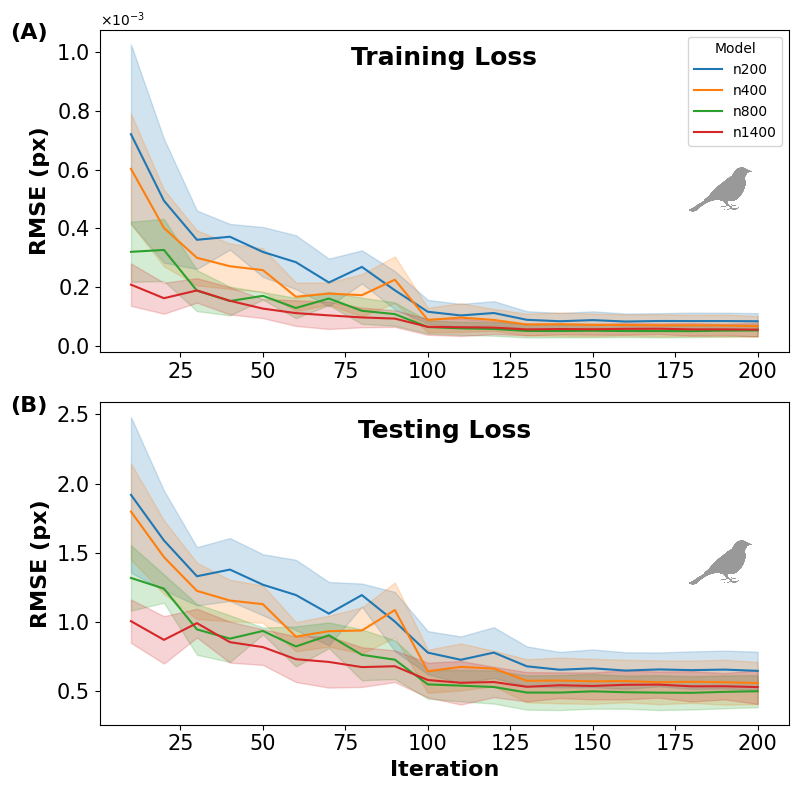

In [123]:
from matplotlib.ticker import ScalarFormatter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
models = all_model_train_Stats["Model"].unique()
palette = dict(zip(models, sns.color_palette("tab10", len(models))))

fig, axes = plt.subplots(2, 1, figsize=(8,8))
bird = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png").convert("RGBA")
bird_image = OffsetImage(
    bird,
    zoom=0.12,
    alpha=0.4
)

bird_box = AnnotationBbox(
    bird_image,
    (0.9, 0.5),
    xycoords="axes fraction",
    frameon=False
)


sns.lineplot(
    data=all_model_train_Stats,
    x="step",
    y="losses/eval.bodypart_total_loss",
    hue="Model",
    hue_order=models,
    palette=palette,
    estimator="mean",
    errorbar="sd",
    ax=axes[0]
)
axes[0].yaxis.set_major_formatter(
    ScalarFormatter(useMathText=True)
)
axes[0].ticklabel_format(
    axis="y",
    style="scientific",
    scilimits=(0, 0)
)

axes[0].text(
    0.5, 0.95,
    "Training Loss",
    transform=axes[0].transAxes,
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold"
)
axes[0].add_artist(bird_box)
axes[0].tick_params(axis="both", labelsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE (px)", fontsize = 16, fontweight="bold")


sns.lineplot(
    data=all_model_train_Stats,
    x="step",
    y="metrics/test.rmse",
    hue="Model",
    hue_order=models,
    palette=palette,
    estimator="mean",
    errorbar="sd",
    ax=axes[1]
)
axes[1].text(
    0.5, 0.95,
    "Testing Loss",
    transform=axes[1].transAxes,
    ha="center",
    va="top",
    fontsize=18,
    fontweight="bold"
)
axes[1].tick_params(axis="both", labelsize=15)
axes[1].set_xlabel("Iteration", fontsize = 16, fontweight="bold")
axes[1].set_ylabel("RMSE (px)", fontsize = 16, fontweight="bold")


bird_box = AnnotationBbox(
    bird_image,
    (0.9, 0.5),
    xycoords="axes fraction",
    frameon=False
)

axes[1].add_artist(bird_box)
# Keep only one legend

# Keep only the legend on the second axes
axes[1].get_legend().remove()
# Panel A label
axes[0].text(
    -0.13, 1.02, "(A)",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold"
)

# Panel B label
axes[1].text(
    -0.13, 1.02, "(B)",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold"
)

axes[0].legend(
    title="Model",
    # bbox_to_anchor=(1.02, 1),
    loc="upper right"
)

plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/TrainingCurvesExp1_Figure.png", dpi=300, bbox_inches="tight", )
plt.show()

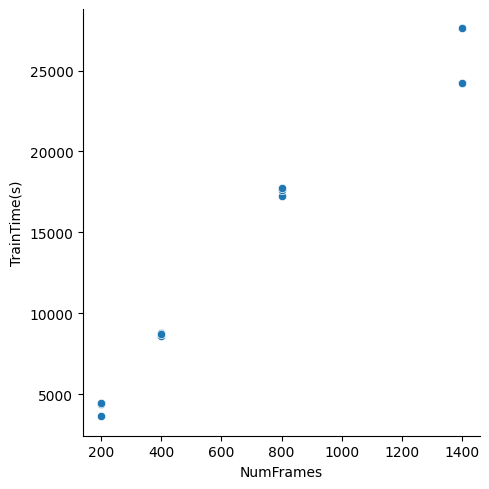

NumFrames
200      4146.800000
400      8684.233333
800     17531.300000
1400    25922.850000
Name: TrainTime(s), dtype: float64

In [72]:
# Plotting Training Time
plot_trainingtime = training_times
sns.relplot(x='NumFrames', y='TrainTime(s)', data=plot_trainingtime)
plt.show()
plot_trainingtime.groupby('NumFrames')['TrainTime(s)'].mean()

In [73]:
from pathlib import Path
import re
import pandas as pd


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(
    r'/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2'
)

OUTPUT_DETAIL = ROOT / "training_times_detailed.csv"
OUTPUT_METHOD = ROOT / "training_times_by_method_and_frames.csv"
OUTPUT_FRAMES = ROOT / "training_times_by_frames.csv"


# ============================================================
# TIME PARSING
# ============================================================

# Matches:
# 2026-07-09 21:34:35
DATETIME_PATTERN = re.compile(
    r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})"
)


def parse_datetime(timestamp):
    """Convert timestamp string to pandas datetime."""
    return pd.to_datetime(timestamp)


def format_seconds(seconds):
    """Convert seconds into HH:MM:SS."""

    if pd.isna(seconds):
        return ""

    seconds = round(seconds)

    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60

    return f"{hours:02d}:{minutes:02d}:{secs:02d}"


# ============================================================
# REGEX FOR TRAINING LINES
# ============================================================

# Example:
#
# 2026-07-09 21:34:35 Epoch 1/125 (lr=0.0005), train loss ...
#
EPOCH_PATTERN = re.compile(
    r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})"
    r".*?Epoch\s+(\d+)/(\d+)"
)


# Matches:
#
# project_path: C:\...\Data\DB_T17\dino_train\nframes_100\ModelsToTune\...
#
PROJECT_PATH_PATTERN = re.compile(
    r"project_path:\s*(.+)$",
    re.IGNORECASE
)


# ============================================================
# EXTRACT METADATA
# ============================================================

def extract_metadata_from_project_path(project_path):
    """
    Extract experiment metadata from the project_path.

    Expected structure such as:

        Data/
          DB_T17/
            dino_train/
              nframes_100/
                ModelsToTune/
                  Canari-FineTuner-...
    """

    # --------------------------------------------------------
    # Normalize Windows path
    # --------------------------------------------------------

    # The project_path is a Windows path even though the
    # Python script is running on Linux.
    normalized = project_path.replace("\\", "/")

    parts = Path(normalized).parts

    # --------------------------------------------------------
    # Animal / trial
    # --------------------------------------------------------

    animal_trial = None
    animal = None
    trial = None

    for part in parts:

        match = re.match(
            r"(.+)_T(\d+)$",
            part,
            re.IGNORECASE
        )

        if match:
            animal_trial = part
            animal = match.group(1)
            trial = int(match.group(2))
            break

    # --------------------------------------------------------
    # Sampling method
    # --------------------------------------------------------

    sampling_method = None

    for part in parts:

        match = re.match(
            r"(.+)_train$",
            part,
            re.IGNORECASE
        )

        if match:
            sampling_method = match.group(1)
            break

    # --------------------------------------------------------
    # Number of frames
    # --------------------------------------------------------

    num_frames = None

    for part in parts:

        match = re.match(
            r"nframes_(\d+)$",
            part,
            re.IGNORECASE
        )

        if match:
            num_frames = int(match.group(1))
            break

    return {
        "project_path": project_path,
        "animal_trial": animal_trial,
        "animal": animal,
        "trial": trial,
        "sampling_method": sampling_method,
        "num_frames": num_frames,
    }


# ============================================================
# EXTRACT TRAINING RUNS
# ============================================================

def get_training_runs(txt_file):
    """
    Extract every training run from a train.txt file.

    Each occurrence of 'project_path:' marks the beginning
    of a new training run.

    For each run:

        start = first Epoch line after project_path
        end   = last Epoch line before next project_path
    """

    text = txt_file.read_text(errors="ignore")

    lines = text.splitlines()

    # --------------------------------------------------------
    # Find project_path lines
    # --------------------------------------------------------

    project_indices = []

    for i, line in enumerate(lines):

        match = PROJECT_PATH_PATTERN.search(line)

        if match:
            project_indices.append(
                (i, match.group(1).strip())
            )

    if not project_indices:
        return []

    runs = []

    # --------------------------------------------------------
    # Process each project_path
    # --------------------------------------------------------

    for run_number, (start_index, project_path) in enumerate(
        project_indices,
        start=1
    ):

        # End of this run is immediately before the next
        # project_path.
        if run_number < len(project_indices):

            end_index = project_indices[run_number][0]

        else:

            end_index = len(lines)

        run_lines = lines[start_index:end_index]

        # ----------------------------------------------------
        # Find Epoch lines
        # ----------------------------------------------------

        epoch_records = []

        for line in run_lines:

            match = EPOCH_PATTERN.search(line)

            if match:

                timestamp = match.group(1)
                epoch = int(match.group(2))
                total_epochs = int(match.group(3))

                epoch_records.append({
                    "timestamp": timestamp,
                    "epoch": epoch,
                    "total_epochs": total_epochs,
                    "line": line,
                })

        # Need at least two Epoch lines
        if len(epoch_records) < 2:

            print(
                f"WARNING: Could not find enough Epoch lines "
                f"for run {run_number}:"
            )

            print(project_path)

            continue

        # ----------------------------------------------------
        # First and last Epoch
        # ----------------------------------------------------

        first_epoch = epoch_records[0]
        last_epoch = epoch_records[-1]

        start_time = parse_datetime(
            first_epoch["timestamp"]
        )

        end_time = parse_datetime(
            last_epoch["timestamp"]
        )

        duration_seconds = (
            end_time - start_time
        ).total_seconds()

        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        metadata = extract_metadata_from_project_path(
            project_path
        )

        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        record = {
            "file": str(txt_file),

            "run_number": run_number,

            **metadata,

            "start_timestamp": first_epoch["timestamp"],
            "end_timestamp": last_epoch["timestamp"],

            "start_epoch": first_epoch["epoch"],
            "end_epoch": last_epoch["epoch"],
            "total_epochs": last_epoch["total_epochs"],

            "training_seconds": duration_seconds,
            "training_time": format_seconds(
                duration_seconds
            ),
        }

        runs.append(record)

    return runs


# ============================================================
# FIND ALL train.txt FILES
# ============================================================

train_files = list(
    ROOT.rglob("train.txt")
)

print(
    f"Found {len(train_files)} train.txt files"
)


# ============================================================
# PROCESS ALL FILES
# ============================================================

records = []

for txt_file in train_files:

    print(
        f"\nProcessing: {txt_file}"
    )

    runs = get_training_runs(txt_file)

    print(
        f"  Found {len(runs)} training run(s)"
    )

    records.extend(runs)


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(records)


if df.empty:

    print(
        "\nWARNING: No training runs were found."
    )

else:

    # Sort for easier inspection
    df = df.sort_values(
        [
            "animal",
            "trial",
            "sampling_method",
            "num_frames",
            "run_number",
        ]
    ).reset_index(drop=True)


# ============================================================
# SAVE DETAILED DATA
# ============================================================

df.to_csv(
    OUTPUT_DETAIL,
    index=False
)

print("\n========================================")
print("DETAILED TRAINING TIMES")
print("========================================")

print(
    df[
        [
            "animal_trial",
            "sampling_method",
            "num_frames",
            "run_number",
            "start_timestamp",
            "end_timestamp",
            "start_epoch",
            "end_epoch",
            "total_epochs",
            "training_time",
        ]
    ].to_string(index=False)
)


# ============================================================
# AVERAGE BY SAMPLING METHOD + NUMBER OF FRAMES
# ============================================================

summary_method = (
    df
    .groupby(
        [
            "sampling_method"
        ]
    )
    .agg(
        n_experiments=(
            "training_seconds",
            "count"
        ),

        mean_seconds=(
            "training_seconds",
            "mean"
        ),

        std_seconds=(
            "training_seconds",
            "std"
        ),

        min_seconds=(
            "training_seconds",
            "min"
        ),

        max_seconds=(
            "training_seconds",
            "max"
        ),
    )
    .reset_index()
)


summary_method["mean_training_time"] = (
    summary_method["mean_seconds"]
    .apply(format_seconds)
)


summary_method["std_training_time"] = (
    summary_method["std_seconds"]
    .apply(
        lambda x:
        format_seconds(x)
        if pd.notna(x)
        else ""
    )
)


summary_method["min_training_time"] = (
    summary_method["min_seconds"]
    .apply(format_seconds)
)


summary_method["max_training_time"] = (
    summary_method["max_seconds"]
    .apply(format_seconds)
)


summary_method.to_csv(
    OUTPUT_METHOD,
    index=False
)


print("\n========================================")
print("AVERAGE BY SAMPLING METHOD + FRAME COUNT")
print("========================================")

print(
    summary_method[
        [
            "sampling_method",
            
            "n_experiments",
            "mean_training_time",
            "std_training_time",
            "min_training_time",
            "max_training_time",
        ]
    ].to_string(index=False)
)


# ============================================================
# AVERAGE ACROSS SAMPLING METHODS
# ============================================================

summary_frames = (
    df
    .groupby(
        ["num_frames"]
    )
    .agg(
        n_experiments=(
            "training_seconds",
            "count"
        ),

        mean_seconds=(
            "training_seconds",
            "mean"
        ),

        std_seconds=(
            "training_seconds",
            "std"
        ),

        min_seconds=(
            "training_seconds",
            "min"
        ),

        max_seconds=(
            "training_seconds",
            "max"
        ),
    )
    .reset_index()
)


summary_frames["mean_training_time"] = (
    summary_frames["mean_seconds"]
    .apply(format_seconds)
)


summary_frames["std_training_time"] = (
    summary_frames["std_seconds"]
    .apply(
        lambda x:
        format_seconds(x)
        if pd.notna(x)
        else ""
    )
)


summary_frames["min_training_time"] = (
    summary_frames["min_seconds"]
    .apply(format_seconds)
)


summary_frames["max_training_time"] = (
    summary_frames["max_seconds"]
    .apply(format_seconds)
)


summary_frames.to_csv(
    OUTPUT_FRAMES,
    index=False
)


print("\n========================================")
print("AVERAGE BY FRAME COUNT")
print("(SAMPLING METHOD AGNOSTIC)")
print("========================================")

print(
    summary_frames[
        [
            "num_frames",
            "n_experiments",
            "mean_training_time",
            "std_training_time",
            "min_training_time",
            "max_training_time",
        ]
    ].to_string(index=False)
)


# ============================================================
# FINISHED
# ============================================================

print("\n========================================")
print("SAVED FILES")
print("========================================")

print(OUTPUT_DETAIL)
print(OUTPUT_METHOD)
print(OUTPUT_FRAMES)

Found 66 train.txt files

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/Endive/Model519/n400_T42/Canari-Tyler-2026-05-22/dlc-models-pytorch/iteration-0/CanariMay22-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/Endive/Model519/n1400_T42/Canari-Tyler-2026-05-22/dlc-models-pytorch/iteration-0/CanariMay22-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/Endive/Model519/n200_T42/Canari-Tyler-2026-05-22/dlc-models-pytorch/iteration-0/CanariMay22-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCut2/Endive/Model519/n800_T42/Canari-Tyler-2026-05-22/dlc-models-pytorch/iteration-0/CanariMay22-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearni

In [74]:
df[df['animal_trial'].str.contains("n")]

,file,run_number,project_path,animal_trial,animal,trial,sampling_method,num_frames,start_timestamp,end_timestamp,start_epoch,end_epoch,total_epochs,training_seconds,training_time
0,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n1400_T15,n1400,15.0,None,None,2026-05-26 17:33:35,2026-05-27 00:17:39,1,200,200,24244.0,06:44:04
1,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n1400_T17,n1400,17.0,None,None,2026-05-27 08:02:46,2026-05-27 15:40:29,1,200,200,27463.0,07:37:43
2,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n1400_T42,n1400,42.0,None,None,2026-05-27 15:42:35,2026-05-27 22:24:28,1,200,200,24113.0,06:41:53
3,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n200_T15,n200,15.0,None,None,2026-05-22 15:59:56,2026-05-22 17:00:03,1,200,200,3607.0,01:00:07
4,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n200_T17,n200,17.0,None,None,2026-05-23 00:14:02,2026-05-23 01:26:27,1,200,200,4345.0,01:12:25
5,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n200_T42,n200,42.0,None,None,2026-05-23 08:43:12,2026-05-23 09:56:52,1,200,200,4420.0,01:13:40
6,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n400_T15,n400,15.0,None,None,2026-05-22 17:00:50,2026-05-22 19:26:17,1,200,200,8727.0,02:25:27
7,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n400_T17,n400,17.0,None,None,2026-05-23 01:27:14,2026-05-23 03:49:27,1,200,200,8533.0,02:22:13
8,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n400_T42,n400,42.0,None,None,2026-05-23 09:57:40,2026-05-23 12:21:52,1,200,200,8652.0,02:24:12
9,/home/kelsey/Documents/TylerMachineLearning/Te...,1,C:\Users\Salle-Cineradio\Documents\MachineLear...,n800_T15,n800,15.0,None,None,2026-05-22 19:27:52,2026-05-23 00:13:39,1,200,200,17147.0,04:45:47


In [75]:
# Plotting All Model Errors
plot_inference_errors = combined_errors
plot_inference_errors.head()

# sns.relplot(x='likelihood', y='distance_px', data=plot_inference_errors, hue='bodypart')

,model,camera,bodypart,frame_id,distance_px,likelihood,pair,train_trial,eval_trial,Bird
0,n1400_T15_200epochs,cam1,Cranium_Left_Anterior,1,70.932056,0.150657,TrainT15_EvalT17,15,17,David Bowie
1,n1400_T15_200epochs,cam1,Cranium_Left_Anterior,2,72.462075,0.127434,TrainT15_EvalT17,15,17,David Bowie
2,n1400_T15_200epochs,cam1,Cranium_Left_Anterior,3,72.418883,0.105338,TrainT15_EvalT17,15,17,David Bowie
3,n1400_T15_200epochs,cam1,Cranium_Left_Anterior,4,72.800645,0.069849,TrainT15_EvalT17,15,17,David Bowie
4,n1400_T15_200epochs,cam1,Cranium_Left_Anterior,5,103.582682,0.047518,TrainT15_EvalT17,15,17,David Bowie


In [76]:
summary = plot_inference_errors.groupby(['model', 'camera'])[['distance_px', 'likelihood']].mean()
# make stats: num_points_within_3pxls
plot_inference_errors['num_points_within_3pxls'] = (
    plot_inference_errors['distance_px'] < 3
)


summary = (
    plot_inference_errors
    .groupby(['train_trial', 'eval_trial'])
    .agg(
        distance_px=('distance_px', 'mean'),
        likelihood=('likelihood', 'mean'),
        percent_within_3pxls=('num_points_within_3pxls', lambda x: x.mean() * 100)
    )
)

summary

distance_px  likelihood  percent_within_3pxls
train_trial eval_trial                                               
15          15             0.525409    0.955961             99.566004
            17             3.336818    0.814921             80.693515
17          15             6.947673    0.771683             64.734890
42          42             0.757673    0.959320             99.416437

In [77]:
print(subepoch_errors['snapshot_num'].unique())
subepoch_errors.head()

[100 125 150]


,camera,bodypart,row_pos,distance_px,frame_id,likelihood,bird,train_trial,eval_trial,pair_slug,numframes,snapshot_num,model_dir
0,cam1,Cranium_Left_Anterior,0,0.346057,1,NaN,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15
1,cam1,Cranium_Left_Anterior,1,0.342422,2,NaN,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15
2,cam1,Cranium_Left_Anterior,2,0.375525,3,NaN,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15
3,cam1,Cranium_Left_Anterior,3,0.522906,4,NaN,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15
4,cam1,Cranium_Left_Anterior,4,0.203881,5,NaN,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15


In [78]:
subepoch_summary.head()

,bird,train_trial,eval_trial,pair_slug,numframes,snapshot_num,model_dir,output_dir,prediction_xmalab_csv,comparison_mode,truth_mode,truth_rows_used,rmse_px,threshold_px,percent_frames_all_points_within_threshold,percent_points_within_threshold,mean_likelihood,n_points
0,DavidBowie,15,15,TrainT15_EvalT15,200,100,n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,1.058071,1.058071,0.696203,85.902652,NaN,66360
1,DavidBowie,15,15,TrainT15_EvalT15,200,125,n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.990144,0.990144,1.392405,87.503014,NaN,66360
2,DavidBowie,15,15,TrainT15_EvalT15,200,150,n200_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.989171,0.989171,2.088608,87.662749,NaN,66360
3,DavidBowie,15,15,TrainT15_EvalT15,400,100,n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.778491,0.778491,0.063291,75.423448,NaN,66360
4,DavidBowie,15,15,TrainT15_EvalT15,400,125,n400_T15,c:\Users\Salle-Cineradio\Documents\MachineLear...,c:\Users\Salle-Cineradio\Documents\MachineLear...,direct_xmalab_rowpos,unused_training_subset,1580,0.720374,0.720374,0.000000,77.169982,NaN,66360


In [79]:
df_plot = subepoch_summary.copy()
# Calculate mean and SD
summary = (
    df_plot.groupby(["Bird_Trial", "num_frames"], as_index=False)
       .agg(
           mean_rmse=("rmse_px", "mean"),
           sd_rmse=("rmse_px", "std"),
           n=("rmse_px", "size"),
       )
)

birds = summary["Bird_Trial"].unique()
frames = sorted(summary["num_frames"].unique())

x = np.arange(len(birds))
offsets = np.linspace(-0.3, 0.3, len(frames))

fig, ax = plt.subplots(figsize=(14, 6))

colors = sns.color_palette("tab10", len(frames))

for i, nf in enumerate(frames):
    sub = (
        summary[summary["num_frames"] == nf]
        .set_index("Bird_Trial")
        .reindex(birds)
    )

    ax.errorbar(
        x + offsets[i],
        sub["mean_rmse"],
        yerr=sub["sd_rmse"],
        fmt="o",
        capsize=4,
        lw=2,
        color=colors[i],
        label=nf,
    )

ax.set_xticks(x)
ax.set_xticklabels(birds, rotation=45, ha="right")
ax.set_ylabel("RMSE (px)")
ax.set_xlabel("Bird Trial")
ax.legend(title="Training Frames")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'Bird_Trial'

# --------------------------------------------------------------------------------------------------------------------------------------------------------------

## Experiment 2
### Found in DeepLabCutExperiments

In [175]:
results_complete = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Results/ModelResults_Complete_Final.csv")
summary_complete = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Results/ModelSummary_Stats.csv")
selectedmodelresults_complete = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Results/SelectedModelResults_Final.csv")
model_builds = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/ModelBuilds_Final.csv")
summary_complete = pd.read_csv("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/evaluation_results/ModelSummary_Final.csv")

In [125]:
from pathlib import Path
import re
import pandas as pd


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(
    r'/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data'
)

OUTPUT_DETAIL = ROOT / "training_times_detailed.csv"
OUTPUT_METHOD = ROOT / "training_times_by_method_and_frames.csv"
OUTPUT_FRAMES = ROOT / "training_times_by_frames.csv"


# ============================================================
# TIME PARSING
# ============================================================

# Matches:
# 2026-07-09 21:34:35
DATETIME_PATTERN = re.compile(
    r"(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})"
)


def parse_datetime(timestamp):
    """Convert timestamp string to pandas datetime."""
    return pd.to_datetime(timestamp)


def format_seconds(seconds):
    """Convert seconds into HH:MM:SS."""

    if pd.isna(seconds):
        return ""

    seconds = round(seconds)

    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60

    return f"{hours:02d}:{minutes:02d}:{secs:02d}"


# ============================================================
# REGEX FOR TRAINING LINES
# ============================================================

# Example:
#
# 2026-07-09 21:34:35 Epoch 1/125 (lr=0.0005), train loss ...
#
EPOCH_PATTERN = re.compile(
    r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})"
    r".*?Epoch\s+(\d+)/(\d+)"
)


# Matches:
#
# project_path: C:\...\Data\DB_T17\dino_train\nframes_100\ModelsToTune\...
#
PROJECT_PATH_PATTERN = re.compile(
    r"project_path:\s*(.+)$",
    re.IGNORECASE
)


# ============================================================
# EXTRACT METADATA
# ============================================================

def extract_metadata_from_project_path(project_path):
    """
    Extract experiment metadata from the project_path.

    Expected structure such as:

        Data/
          DB_T17/
            dino_train/
              nframes_100/
                ModelsToTune/
                  Canari-FineTuner-...
    """

    # --------------------------------------------------------
    # Normalize Windows path
    # --------------------------------------------------------

    # The project_path is a Windows path even though the
    # Python script is running on Linux.
    normalized = project_path.replace("\\", "/")

    parts = Path(normalized).parts

    # --------------------------------------------------------
    # Animal / trial
    # --------------------------------------------------------

    animal_trial = None
    animal = None
    trial = None

    for part in parts:

        match = re.match(
            r"(.+)_T(\d+)$",
            part,
            re.IGNORECASE
        )

        if match:
            animal_trial = part
            animal = match.group(1)
            trial = int(match.group(2))
            break

    # --------------------------------------------------------
    # Sampling method
    # --------------------------------------------------------

    sampling_method = None

    for part in parts:

        match = re.match(
            r"(.+)_train$",
            part,
            re.IGNORECASE
        )

        if match:
            sampling_method = match.group(1)
            break

    # --------------------------------------------------------
    # Number of frames
    # --------------------------------------------------------

    num_frames = None

    for part in parts:

        match = re.match(
            r"nframes_(\d+)$",
            part,
            re.IGNORECASE
        )

        if match:
            num_frames = int(match.group(1))
            break

    return {
        "project_path": project_path,
        "animal_trial": animal_trial,
        "animal": animal,
        "trial": trial,
        "sampling_method": sampling_method,
        "num_frames": num_frames,
    }


# ============================================================
# EXTRACT TRAINING RUNS
# ============================================================

def get_training_runs(txt_file):
    """
    Extract every training run from a train.txt file.

    Each occurrence of 'project_path:' marks the beginning
    of a new training run.

    For each run:

        start = first Epoch line after project_path
        end   = last Epoch line before next project_path
    """

    text = txt_file.read_text(errors="ignore")

    lines = text.splitlines()

    # --------------------------------------------------------
    # Find project_path lines
    # --------------------------------------------------------

    project_indices = []

    for i, line in enumerate(lines):

        match = PROJECT_PATH_PATTERN.search(line)

        if match:
            project_indices.append(
                (i, match.group(1).strip())
            )

    if not project_indices:
        return []

    runs = []

    # --------------------------------------------------------
    # Process each project_path
    # --------------------------------------------------------

    for run_number, (start_index, project_path) in enumerate(
        project_indices,
        start=1
    ):

        # End of this run is immediately before the next
        # project_path.
        if run_number < len(project_indices):

            end_index = project_indices[run_number][0]

        else:

            end_index = len(lines)

        run_lines = lines[start_index:end_index]

        # ----------------------------------------------------
        # Find Epoch lines
        # ----------------------------------------------------

        epoch_records = []

        for line in run_lines:

            match = EPOCH_PATTERN.search(line)

            if match:

                timestamp = match.group(1)
                epoch = int(match.group(2))
                total_epochs = int(match.group(3))

                epoch_records.append({
                    "timestamp": timestamp,
                    "epoch": epoch,
                    "total_epochs": total_epochs,
                    "line": line,
                })

        # Need at least two Epoch lines
        if len(epoch_records) < 2:

            print(
                f"WARNING: Could not find enough Epoch lines "
                f"for run {run_number}:"
            )

            print(project_path)

            continue

        # ----------------------------------------------------
        # First and last Epoch
        # ----------------------------------------------------

        first_epoch = epoch_records[0]
        last_epoch = epoch_records[-1]

        start_time = parse_datetime(
            first_epoch["timestamp"]
        )

        end_time = parse_datetime(
            last_epoch["timestamp"]
        )

        duration_seconds = (
            end_time - start_time
        ).total_seconds()

        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        metadata = extract_metadata_from_project_path(
            project_path
        )

        # ----------------------------------------------------
        # Save result
        # ----------------------------------------------------

        record = {
            "file": str(txt_file),

            "run_number": run_number,

            **metadata,

            "start_timestamp": first_epoch["timestamp"],
            "end_timestamp": last_epoch["timestamp"],

            "start_epoch": first_epoch["epoch"],
            "end_epoch": last_epoch["epoch"],
            "total_epochs": last_epoch["total_epochs"],

            "training_seconds": duration_seconds,
            "training_time": format_seconds(
                duration_seconds
            ),
        }

        runs.append(record)

    return runs


# ============================================================
# FIND ALL train.txt FILES
# ============================================================

train_files = list(
    ROOT.rglob("train.txt")
)

print(
    f"Found {len(train_files)} train.txt files"
)


# ============================================================
# PROCESS ALL FILES
# ============================================================

records = []

for txt_file in train_files:

    print(
        f"\nProcessing: {txt_file}"
    )

    runs = get_training_runs(txt_file)

    print(
        f"  Found {len(runs)} training run(s)"
    )

    records.extend(runs)


# ============================================================
# CREATE DATAFRAME
# ============================================================

df = pd.DataFrame(records)


if df.empty:

    print(
        "\nWARNING: No training runs were found."
    )

else:

    # Sort for easier inspection
    df = df.sort_values(
        [
            "animal",
            "trial",
            "sampling_method",
            "num_frames",
            "run_number",
        ]
    ).reset_index(drop=True)


# ============================================================
# SAVE DETAILED DATA
# ============================================================

df.to_csv(
    OUTPUT_DETAIL,
    index=False
)

print("\n========================================")
print("DETAILED TRAINING TIMES")
print("========================================")

print(
    df[
        [
            "animal_trial",
            "sampling_method",
            "num_frames",
            "run_number",
            "start_timestamp",
            "end_timestamp",
            "start_epoch",
            "end_epoch",
            "total_epochs",
            "training_time",
        ]
    ].to_string(index=False)
)


# ============================================================
# AVERAGE BY SAMPLING METHOD + NUMBER OF FRAMES
# ============================================================

summary_method = (
    df
    .groupby(
        [
            "sampling_method"
        ]
    )
    .agg(
        n_experiments=(
            "training_seconds",
            "count"
        ),

        mean_seconds=(
            "training_seconds",
            "mean"
        ),

        std_seconds=(
            "training_seconds",
            "std"
        ),

        min_seconds=(
            "training_seconds",
            "min"
        ),

        max_seconds=(
            "training_seconds",
            "max"
        ),
    )
    .reset_index()
)


summary_method["mean_training_time"] = (
    summary_method["mean_seconds"]
    .apply(format_seconds)
)


summary_method["std_training_time"] = (
    summary_method["std_seconds"]
    .apply(
        lambda x:
        format_seconds(x)
        if pd.notna(x)
        else ""
    )
)


summary_method["min_training_time"] = (
    summary_method["min_seconds"]
    .apply(format_seconds)
)


summary_method["max_training_time"] = (
    summary_method["max_seconds"]
    .apply(format_seconds)
)


summary_method.to_csv(
    OUTPUT_METHOD,
    index=False
)


print("\n========================================")
print("AVERAGE BY SAMPLING METHOD + FRAME COUNT")
print("========================================")

print(
    summary_method[
        [
            "sampling_method",
            
            "n_experiments",
            "mean_training_time",
            "std_training_time",
            "min_training_time",
            "max_training_time",
        ]
    ].to_string(index=False)
)


# ============================================================
# AVERAGE ACROSS SAMPLING METHODS
# ============================================================

summary_frames = (
    df
    .groupby(
        ["num_frames"]
    )
    .agg(
        n_experiments=(
            "training_seconds",
            "count"
        ),

        mean_seconds=(
            "training_seconds",
            "mean"
        ),

        std_seconds=(
            "training_seconds",
            "std"
        ),

        min_seconds=(
            "training_seconds",
            "min"
        ),

        max_seconds=(
            "training_seconds",
            "max"
        ),
    )
    .reset_index()
)


summary_frames["mean_training_time"] = (
    summary_frames["mean_seconds"]
    .apply(format_seconds)
)


summary_frames["std_training_time"] = (
    summary_frames["std_seconds"]
    .apply(
        lambda x:
        format_seconds(x)
        if pd.notna(x)
        else ""
    )
)


summary_frames["min_training_time"] = (
    summary_frames["min_seconds"]
    .apply(format_seconds)
)


summary_frames["max_training_time"] = (
    summary_frames["max_seconds"]
    .apply(format_seconds)
)


summary_frames.to_csv(
    OUTPUT_FRAMES,
    index=False
)


print("\n========================================")
print("AVERAGE BY FRAME COUNT")
print("(SAMPLING METHOD AGNOSTIC)")
print("========================================")

print(
    summary_frames[
        [
            "num_frames",
            "n_experiments",
            "mean_training_time",
            "std_training_time",
            "min_training_time",
            "max_training_time",
        ]
    ].to_string(index=False)
)


# ============================================================
# FINISHED
# ============================================================

print("\n========================================")
print("SAVED FILES")
print("========================================")

print(OUTPUT_DETAIL)
print(OUTPUT_METHOD)
print(OUTPUT_FRAMES)

Found 108 train.txt files

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Tulio_T56/dino_train/nframes_100/ModelsToTune/Canari-FineTuner-2026-07-21/dlc-models-pytorch/iteration-0/CanariJul21-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Tulio_T56/dino_train/nframes_50/ModelsToTune/Canari-FineTuner-2026-07-21/dlc-models-pytorch/iteration-0/CanariJul21-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Tulio_T56/displacement_train/nframes_100/ModelsToTune/Canari-FineTuner-2026-07-21/dlc-models-pytorch/iteration-0/CanariJul21-trainset95shuffle1/train/train.txt
  Found 1 training run(s)

Processing: /home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Tulio_T56/displacement_train/nframes_50/ModelsToTune/Canari-FineT

In [ ]:
summary_frames

,num_frames,n_experiments,mean_seconds,std_seconds,min_seconds,max_seconds,mean_training_time,std_training_time,min_training_time,max_training_time
0,50,68,607.602941,295.828265,271.0,1963.0,00:10:08,00:04:56,00:04:31,00:32:43
1,100,71,1201.126761,684.156079,69.0,4794.0,00:20:01,00:11:24,00:01:09,01:19:54


In [ ]:
summary_method

,sampling_method,n_experiments,mean_seconds,std_seconds,min_seconds,max_seconds,mean_training_time,std_training_time,min_training_time,max_training_time
0,dino,45,918.155556,566.450309,535.0,3998.0,00:15:18,00:09:26,00:08:55,01:06:38
1,displacement,46,911.891304,586.546663,271.0,4144.0,00:15:12,00:09:47,00:04:31,01:09:04
2,random,48,902.770833,672.541678,69.0,4794.0,00:15:03,00:11:13,00:01:09,01:19:54


### Model Selection
To be done for both species to show different types of data

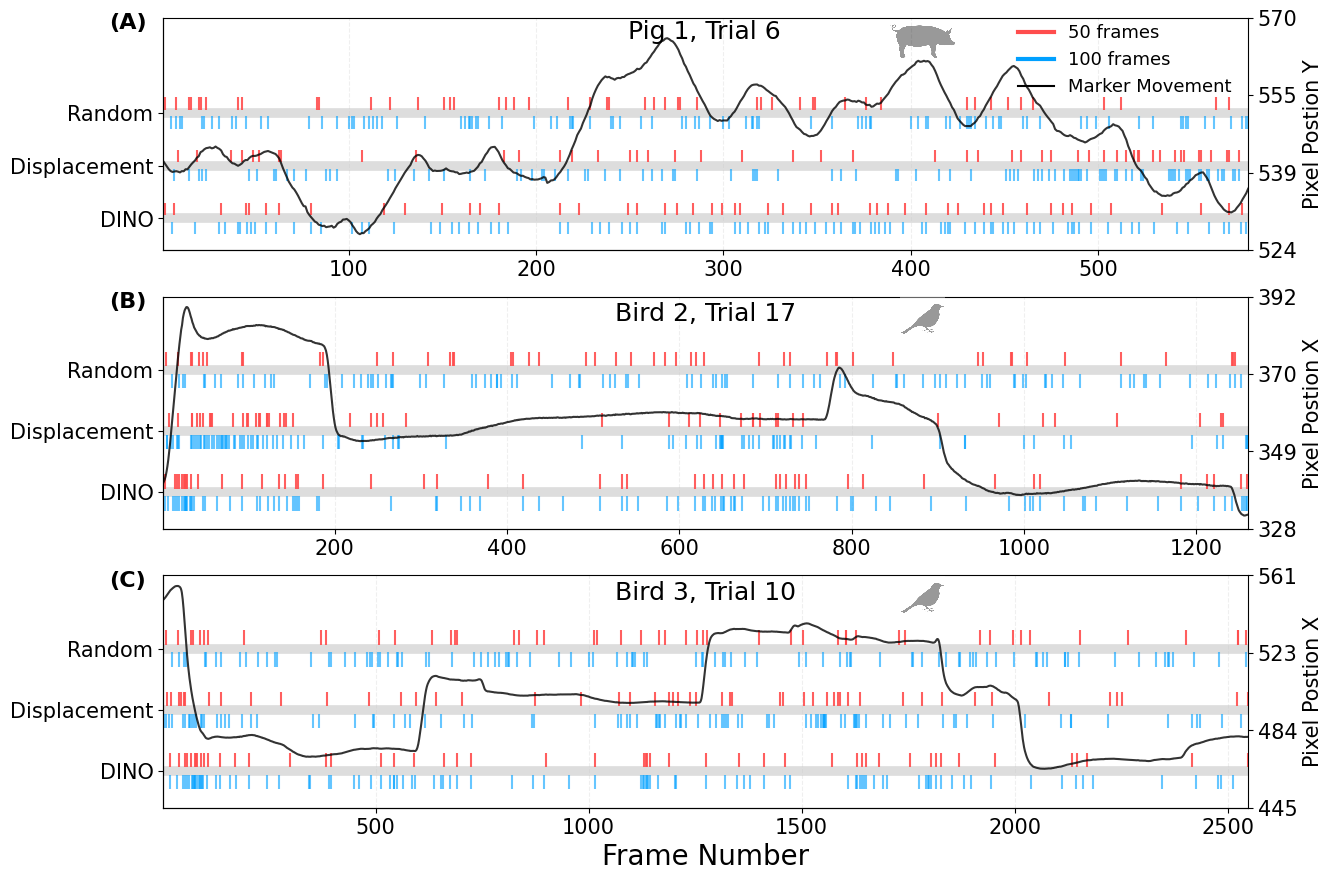

In [139]:
import json
from matplotlib.ticker import LinearLocator, FuncFormatter


ANIMAL_TRIALS = {
    "Pig": {"trial": "Pig_T6"},
    "DavidBowie": {"trial": "DB_T17"},
    "Tulio": {"trial": "Tulio_T10"},
}

METHOD_DIRS = {
    "Random": "random_train",
    "Displacement": "displacement_train",
    "DINO": "dino_train",
}

FRAME_COUNTS = [50, 100]
FRAME_COLORS = {50: "#ff4d4d", 100: "#00a0ff"}
FRAME_ALPHA = {50:  .9, 100: .6}
DATA_ROOT = Path("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data")


def _load_selected_indices(trial: str, method_dir: str, nframes: int) -> np.ndarray:
    meta_path = DATA_ROOT / trial / method_dir / f"nframes_{nframes}" / "dataset_build_metadata.json"
    if not meta_path.exists():
        return np.array([], dtype=int)
    with open(meta_path, "r") as f:
        meta = json.load(f)
    idx = meta.get("selected_indices", [])
    return np.asarray(sorted(idx), dtype=int)


methods = list(METHOD_DIRS.keys())
y_positions = np.arange(len(methods), 0, -1)


fig, axes = plt.subplots(
    nrows=len(ANIMAL_TRIALS),
    ncols=1,
    figsize=(14, 10),
    gridspec_kw={"height_ratios": [1, 1, 1]},
    constrained_layout=False,
)

fig.subplots_adjust(
    top=0.90,
    
)

if len(ANIMAL_TRIALS) == 1:
    axes = [axes]

for ax, (animal, cfg) in zip(axes, ANIMAL_TRIALS.items()):
    trial = cfg["trial"]


    coords_df = pd.read_csv(DATA_ROOT / trial / "CompleteSet" / "LabeledBodyPartsCoordinates.csv")
    if animal == "Pig":
        animal_name = "Pig 1"
        axis = 'Y'

    else:
        if animal == 'Tulio':
            animal_name = "Bird 3"
        else:
            animal_name = 'Bird 2'
        axis = 'X'
    point_cols = [
        col for col in coords_df.columns
        if col.endswith(axis) and "cam1" in col
    ]

    yvals = coords_df[point_cols].apply(
        pd.to_numeric, errors="coerce"
    ).mean(axis=1).to_numpy(dtype=float)
    xvals = np.arange(1, len(yvals) + 1, dtype=int)  # 1-based frame numbers
    valid = np.isfinite(yvals)

    ax2 = ax.twinx()
    if np.any(valid):
        ax2.plot(
            xvals[valid],
            yvals[valid],
            color="black",
            linewidth=1.5,
            alpha=0.8,
            zorder=1,
            
        )
    ax2.set_ylabel(f'Pixel Postion {axis}', fontsize=15)
    ax2.yaxis.set_major_locator(LinearLocator(4))
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0f}"))
    ax2.tick_params(axis="y", labelsize=15)
    if animal == "Pig":
        ax2.set_ylim(524, 570)
    ax2.spines["right"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    ax2.grid(False)
    ax2.patch.set_alpha(0)
    max_selected = 0
    for method, y in zip(methods, y_positions):
        ax.hlines(y, 1, max(len(yvals), 2), color="#c7c7c7", linewidth=7, alpha=0.6)
        for nframes in FRAME_COUNTS:
            # metadata indices are 0-based frame positions within the series
            selected_frames = _load_selected_indices(trial, METHOD_DIRS[method], nframes) + 1
            selected_frames = selected_frames[(selected_frames >= 1) & (selected_frames <= len(yvals))]
            max_selected = max(max_selected, selected_frames.max())
            FRAME_Y_OFFSET = {
                50: 0.18,    # above
                100: -0.18,  # below
            }
        

            if selected_frames.size:
                
                offset = FRAME_Y_OFFSET[nframes]

                ax.vlines(
                    selected_frames,
                    y + offset - 0.12,
                    y + offset + 0.12,
                    color=FRAME_COLORS[nframes],
                    linewidth=1.5,
                    alpha=FRAME_ALPHA[nframes],
                    label=f"{nframes} frames",
                    zorder=5,
                )
    if animal == 'Pig':
        offset = 1.4
    else: 
        offset = .8
    ax.text(max_selected/2, len(methods) + offset, f"{animal_name}, Trial {trial.split('_')[1][1:]}", fontsize=18, ha="center")
    ax.set_xlim(1, max_selected)
    if ax is axes[0]:
        ax.set_ylim(0.4, len(methods) + 1.8)
    else:
        ax.set_ylim(0.4, len(methods) + 1.2)

    ax.set_yticks(y_positions)
    ax.set_yticklabels(methods, size = 15)
    ax.grid(axis="x", alpha=0.2, linestyle="--")
axes[0].tick_params(axis='both', labelsize=15)
axes[1].tick_params(axis='both', labelsize=15)
axes[2].tick_params(axis='both', labelsize=15)
axes[-1].set_xlabel("Frame Number", size = 20)

# Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png").convert("RGBA")
pig = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Pig_Silhouette.png").convert("RGBA")
pig_img = OffsetImage(
    pig,
    zoom=0.06,
    alpha=0.4
)

pig_box = AnnotationBbox(
    pig_img,
    (0.7, 0.9),
    xycoords="axes fraction",
    frameon=False
)

axes[0].add_artist(pig_box)

bird_image = OffsetImage(
    bird,
    zoom=0.08,
    alpha=0.4
)

bird_box = AnnotationBbox(
    bird_image,
    (0.7, 0.9),
    xycoords="axes fraction",
    frameon=False
)

axes[1].add_artist(bird_box)

bird_box = AnnotationBbox(
    bird_image,
    (0.7, 0.9),
    xycoords="axes fraction",
    frameon=False
)

axes[2].add_artist(bird_box)

axes[0].text(
    -0.05, 1.02, "(A)",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold"
)

# Panel B label
axes[1].text(
    -0.05, 1.02, "(B)",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold"
)

# Panel C label
axes[2].text(
    -0.05, 1.02, "(C)",
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=16,
    fontweight="bold"
)

handles = [Line2D([0], [0], color=FRAME_COLORS[n], lw=3, label=f"{n} frames") for n in FRAME_COUNTS]
handles.append(Line2D([0], [0], color="black", lw=1.5, label="Marker Movement"))
fig.legend(
    handles=handles,
    loc="upper right",
    bbox_to_anchor=(0.90, 0.91),
    frameon=False,
    fontsize=13,
)
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/SelectedFramesLinear_Figure.png", dpi=300, bbox_inches="tight", )
plt.show()

In [86]:
import pickle
import pathlib

# Make WindowsPath loadable on Linux
pathlib.WindowsPath = pathlib.PosixPath

DATA_ROOT = pathlib.Path(
    "/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data"
)

OUTPUT_EMBEDDINGS = DATA_ROOT / "embedding_results.pkl"

with open(OUTPUT_EMBEDDINGS, "rb") as f:
    embedding_results = pickle.load(f)

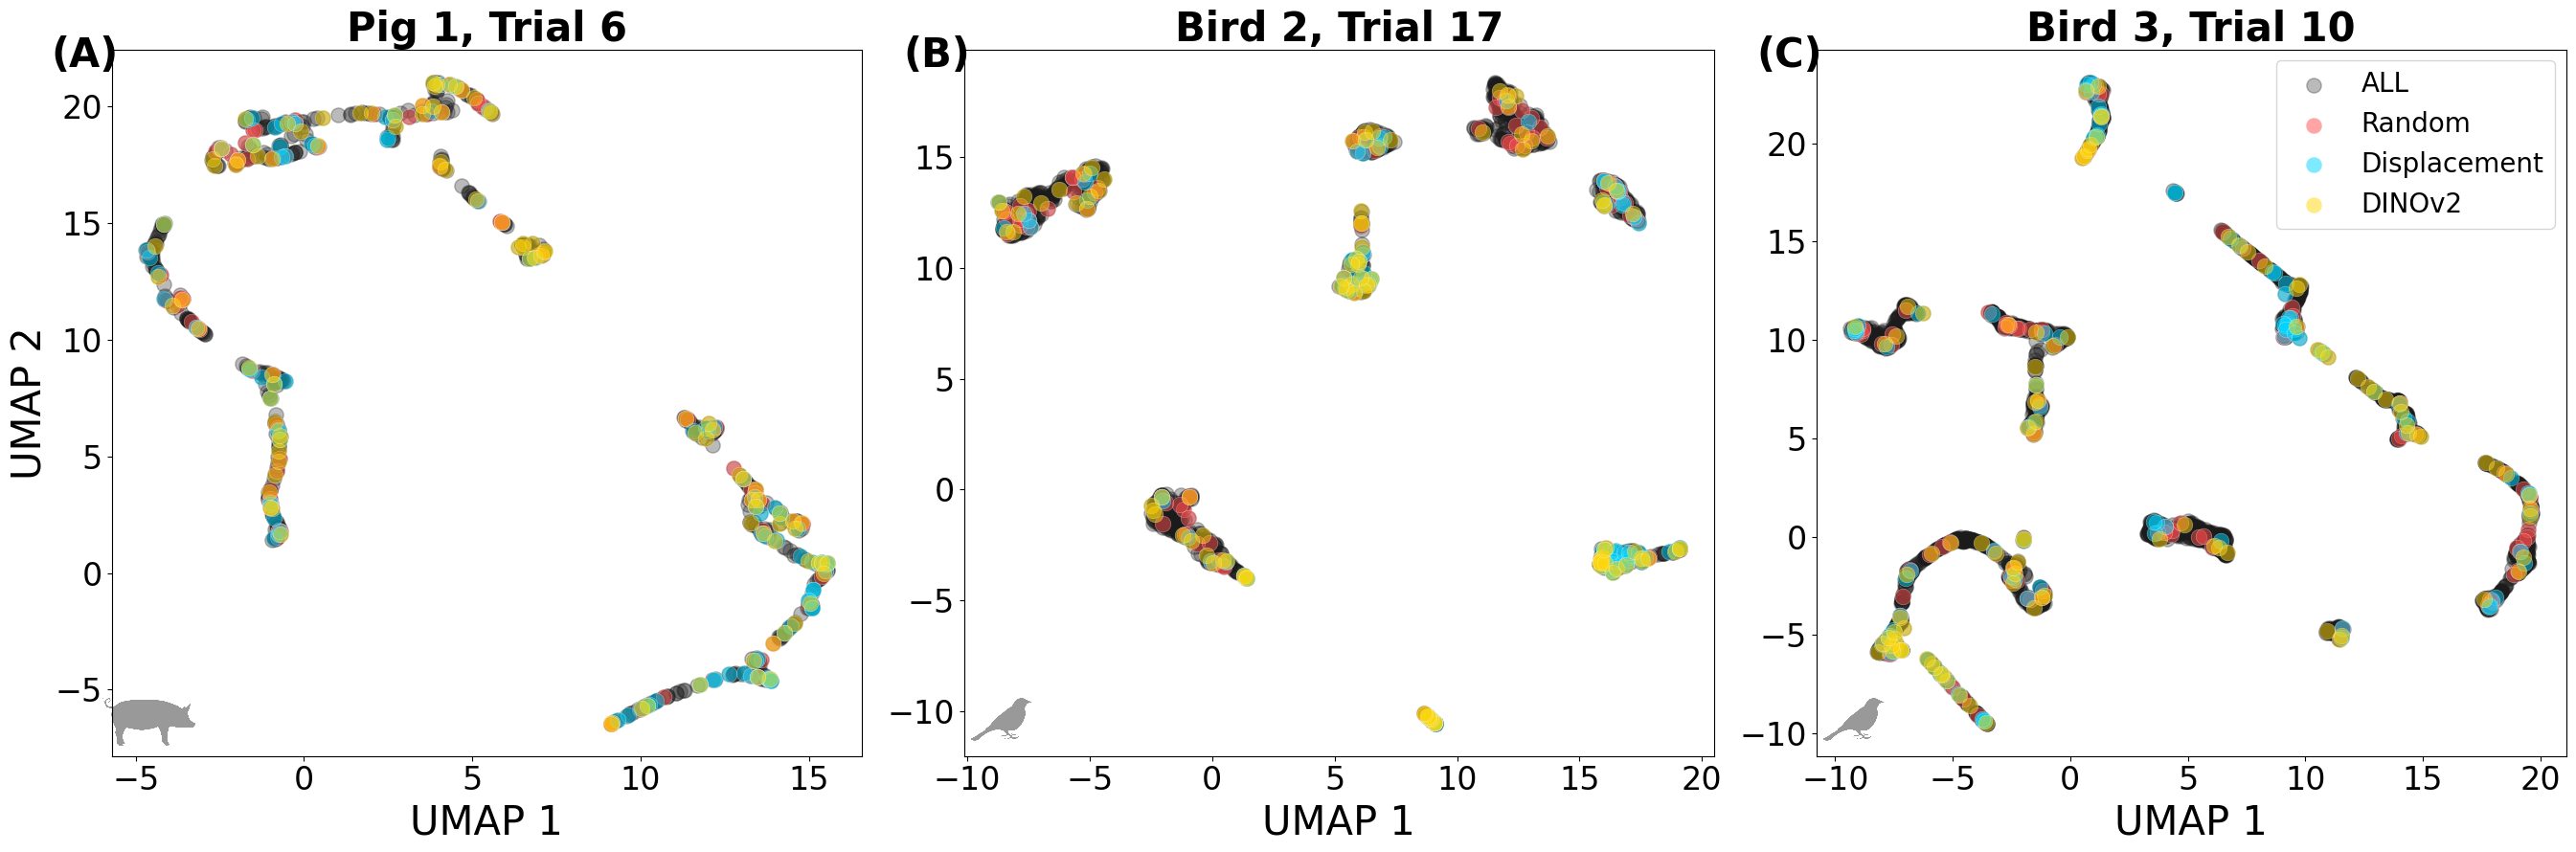

In [158]:
import matplotlib.pyplot as plt
import numpy as np
umap =True

# ============================================================
# COLORS
# ============================================================

overlay_specs = [
    ("random", "#ff4d4d"),
    ("displacement", "#00d4ff"),
    ("dino", "#ffd60a"),
]


# ============================================================
# 1 x N GRID
# ============================================================

n_trials = len(embedding_results)

fig, axes = plt.subplots(
    1,
    n_trials,
    figsize=(9 * n_trials, 9),
    squeeze=False,
)

axes = axes[0]


for ax, result in zip(axes, embedding_results):

    embedding_2d = result["embedding_2d"]
    method_to_indices = result["method_to_indices"]

    # --------------------------------------------------------
    # All images: dark background cloud
    # --------------------------------------------------------

    ax.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        s=120,
        alpha=0.3,
        c="#1b1b1b",
        label="all_images",
    )

    # --------------------------------------------------------
    # Training selections
    # --------------------------------------------------------

    for method_name, color in overlay_specs:

        idx = method_to_indices.get(
            method_name,
            np.asarray([], dtype=int)
        )

        if idx.size == 0:
            continue

        ax.scatter(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            s=145,
            alpha=0.5,
            c=color,
            edgecolors="white",
            linewidths=0.35,
            label=(
                f"{method_name}_train "
                f"(n={idx.size})"
            ),
        )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    


    ax.set_xlabel(
        "UMAP 1" if umap is not None else "PC 1",
        fontsize=30,
    )

    ax.set_ylabel(
        "UMAP 2" if umap is not None else "PC 2",
        fontsize=30,
    )

    ax.tick_params(
        labelsize=24
    )

    axes[1].set_ylabel("")
    axes[2].set_ylabel("")

# ============================================================
# ONE SHARED LEGEND
# ============================================================

handles, labels = axes[2].get_legend_handles_labels()

labels = ["ALL", "Random", "Displacement", "DINOv2"]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.995, 0.94),
    ncol=1,
    frameon=True,
    fontsize=20,
)

pig = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Pig_Silhouette.png").convert("RGBA")
bird = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png").convert("RGBA")
pig_img = OffsetImage(
    pig,
    zoom=0.09,
    alpha=0.4
)

axes[0].set_title(f"Pig 1, Trial 6", fontsize=30, ha="center", fontweight="bold")
axes[0].text(
    -0.08, 1.02, "(A)",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=30,
    fontweight="bold"
)
axes[1].set_title(f"Bird 2, Trial 17", fontsize=30, ha="center", fontweight="bold")
# Panel B label
axes[1].text(
    -0.08, 1.02, "(B)",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=30,
    fontweight="bold"
)
axes[2].set_title(f"Bird 3, Trial 10", fontsize=30, ha="center", fontweight="bold")
# Panel C label
axes[2].text(
    -0.08, 1.02, "(C)",
    transform=axes[2].transAxes,
    ha="left",
    va="top",
    fontsize=30,
    fontweight="bold"
)

pig_box = AnnotationBbox(
    pig_img,
    (0.05, 0.05),
    xycoords="axes fraction",
    frameon=False
)

axes[0].add_artist(pig_box)

bird_image = OffsetImage(
    bird,
    zoom=0.12,
    alpha=0.4
)

bird_box = AnnotationBbox(
    bird_image,
    (0.05, 0.05),
    xycoords="axes fraction",
    frameon=False
)

axes[1].add_artist(bird_box)

bird_box = AnnotationBbox(
    bird_image,
    (0.05, 0.05),
    xycoords="axes fraction",
    frameon=False
)

axes[2].add_artist(bird_box)


# ============================================================
# FINAL LAYOUT
# ============================================================

plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/All_Trial_Embeddings_Figure.png")
plt.show()

### Results for Small Input Study

In [88]:
results_complete.head()

,Unnamed: 0,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,...,percent_frames_all_points_within_threshold_baseline,percent_frames_all_points_within_threshold_blobDetect,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type
0,0,Pig,1,1.0,dino,50,3.670955,3.617743,-0.053212,98.066667,...,68.666667,90.666667,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within
1,36,Pig,4,1.0,dino,50,48.354243,48.554452,0.200208,62.716667,...,0.333333,7.666667,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across
2,72,Pig,6,1.0,dino,50,21.860326,21.851076,-0.009250,90.983333,...,7.666667,67.333333,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across
3,108,Pig,41,1.0,dino,50,1.904320,1.792996,-0.111324,97.100000,...,56.333333,90.666667,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,across
4,144,Pig,46,1.0,dino,50,7.484299,7.344179,-0.140120,91.350000,...,17.666667,78.000000,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across


In [190]:
from itertools import combinations
from scipy.stats import ttest_rel
import pandas as pd
selectedmodelresults_complete['Animal'] = np.where(
    selectedmodelresults_complete['bird'] == 'Pig',
    'Pig',
    'Bird'
)
group_cols = ["method", "pair_type", "Animal", "nframes", "CombinedModel"]

metric_pairs = [
    ("Baseline_Percent", "BlobDetect_Percent",
     "percent_points_within_threshold_baseline",
     "percent_points_within_threshold_blobDetect"),

    ("Baseline_RMSE", "BlobDetect_RMSE",
     "rmse_px_baseline",
     "rmse_px_blobDetect"),
]

groupings = [()]
groupings.extend((c,) for c in group_cols)
groupings.extend(combinations(group_cols, 2))
# groupings.extend(combinations(group_cols, 3))

tables = []

for groups in groupings:

    if len(groups) == 0:
        grouped = [((), selectedmodelresults_complete)]
    else:
        grouped = selectedmodelresults_complete.groupby(list(groups))

    rows = []

    for key, df in grouped:

        row = {}

        if len(groups) > 0:
            if len(groups) == 1:
                row[groups[0]] = str(key[0])
            else:
                for c, v in zip(groups, key):
                    row[c] = v

        row["N"] = len(df)

        # Summary statistics
        for label_base, label_blob, col_base, col_blob in metric_pairs:

            row[label_base] = f"{df[col_base].mean():.2f} ± {df[col_base].std():.2f}"
            row[label_blob] = f"{df[col_blob].mean():.2f} ± {df[col_blob].std():.2f}"

        # Paired t-tests
        p_percent = ttest_rel(
            df["percent_points_within_threshold_baseline"],
            df["percent_points_within_threshold_blobDetect"],
            nan_policy="omit"
        ).pvalue

        p_rmse = ttest_rel(
            df["rmse_px_baseline"],
            df["rmse_px_blobDetect"],
            nan_policy="omit"
        ).pvalue

        row["Percent p"] = f"{p_percent:.3g}"
        row["RMSE p"] = f"{p_rmse:.3g}"

        rows.append(row)

    summary = pd.DataFrame(rows)

    # Add missing grouping columns
    for col in group_cols:
        if col not in summary.columns:
            summary[col] = ""

    summary.insert(
        0,
        "Aggregation",
        "Overall" if len(groups) == 0 else " + ".join(groups)
    )

    summary = summary[
        ["Aggregation"] + group_cols + [
            "N",
            "Baseline_Percent",
            "BlobDetect_Percent",
            "Percent p",
            "Baseline_RMSE",
            "BlobDetect_RMSE",
            "RMSE p",
        ]
    ]

    tables.append(summary)

final_summary_p = pd.concat(tables, ignore_index=True)
# final_summary_p.to_csv(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Data/Results/ModelSummary_Stats.csv")
final_summary_p

,Aggregation,method,pair_type,Animal,nframes,CombinedModel,N,Baseline_Percent,BlobDetect_Percent,Percent p,Baseline_RMSE,BlobDetect_RMSE,RMSE p
0,Overall,,,,,,360,80.28 ± 19.65,88.00 ± 12.57,1.2e-39,19.12 ± 24.00,19.30 ± 23.92,1.38e-19
1,method,dino,,,,,120,81.07 ± 19.39,88.42 ± 12.79,6.6e-14,18.88 ± 24.35,19.06 ± 24.26,9.48e-08
2,method,displacement,,,,,120,79.87 ± 19.94,87.78 ± 12.61,2.17e-14,18.98 ± 24.13,19.16 ± 24.05,6.36e-08
3,method,random,,,,,120,79.90 ± 19.75,87.78 ± 12.40,2.98e-14,19.52 ± 23.72,19.68 ± 23.63,1.11e-06
4,pair_type,,across,,,,192,66.23 ± 16.68,79.49 ± 11.79,3.45e-44,32.46 ± 26.02,32.53 ± 26.01,8.61e-05
5,pair_type,,within,,,,168,96.35 ± 4.95,97.72 ± 1.48,1.62e-05,3.88 ± 5.13,4.18 ± 4.98,2.45e-17
6,Animal,,,Bird,,,216,77.45 ± 22.39,88.10 ± 12.08,2.98e-30,17.14 ± 26.39,17.42 ± 26.24,8.16e-19
7,Animal,,,Pig,,,144,84.53 ± 13.61,87.84 ± 13.31,1.93e-45,22.10 ± 19.62,22.13 ± 19.69,0.00128
8,nframes,,,,50,,180,78.55 ± 19.88,87.35 ± 12.98,1.91e-24,20.36 ± 24.81,20.50 ± 24.76,2.65e-08
9,nframes,,,,100,,180,82.02 ± 19.31,88.64 ± 12.14,4.82e-17,17.89 ± 23.17,18.10 ± 23.06,8.06e-13


In [90]:
from scipy.stats import ttest_rel
import numpy as np

# ============================================================
# PERCENT WITHIN THRESHOLD
# ============================================================

percent_baseline = df[
    "percent_points_within_threshold_baseline"
]

percent_blob = df[
    "percent_points_within_threshold_blobDetect"
]

# Paired differences
percent_diff = percent_blob - percent_baseline

# Remove pairs with missing values
mask = (
    percent_baseline.notna()
    & percent_blob.notna()
)

percent_baseline = percent_baseline[mask]
percent_blob = percent_blob[mask]
percent_diff = percent_diff[mask]

# Test
t_percent, p_percent = ttest_rel(
    percent_baseline,
    percent_blob
)

# Statistics
n_percent = len(percent_diff)
mean_diff_percent = percent_diff.mean()
sd_diff_percent = percent_diff.std(ddof=1)
se_percent = sd_diff_percent / np.sqrt(n_percent)

# 95% CI
from scipy.stats import t

critical = t.ppf(
    0.975,
    df=n_percent - 1
)

ci_low_percent = mean_diff_percent - critical * se_percent
ci_high_percent = mean_diff_percent + critical * se_percent


# ============================================================
# RMSE
# ============================================================

rmse_baseline = df["rmse_px_baseline"]
rmse_blob = df["rmse_px_blobDetect"]

mask = (
    rmse_baseline.notna()
    & rmse_blob.notna()
)

rmse_baseline = rmse_baseline[mask]
rmse_blob = rmse_blob[mask]

rmse_diff = rmse_blob - rmse_baseline

t_rmse, p_rmse = ttest_rel(
    rmse_baseline,
    rmse_blob
)

n_rmse = len(rmse_diff)

mean_diff_rmse = rmse_diff.mean()
sd_diff_rmse = rmse_diff.std(ddof=1)
se_rmse = sd_diff_rmse / np.sqrt(n_rmse)

critical = t.ppf(
    0.975,
    df=n_rmse - 1
)

ci_low_rmse = mean_diff_rmse - critical * se_rmse
ci_high_rmse = mean_diff_rmse + critical * se_rmse


# ============================================================
# PRINT RESULTS
# ============================================================

print("========================================")
print("BASELINE vs BLOBDTECT")
print("========================================")

print("\nPercent within threshold")
print("----------------------------------------")

print(
    f"Baseline: "
    f"{percent_baseline.mean():.2f} ± "
    f"{percent_baseline.std():.2f}%"
)

print(
    f"BlobDetect: "
    f"{percent_blob.mean():.2f} ± "
    f"{percent_blob.std():.2f}%"
)

print(
    f"Mean difference (BlobDetect - Baseline): "
    f"{mean_diff_percent:.2f} percentage points"
)

print(
    f"95% CI: "
    f"[{ci_low_percent:.2f}, {ci_high_percent:.2f}]"
)

print(
    f"t({n_percent-1}) = {t_percent:.3f}, "
    f"p = {p_percent:.4g}"
)


print("\nRMSE")
print("----------------------------------------")

print(
    f"Baseline: "
    f"{rmse_baseline.mean():.2f} ± "
    f"{rmse_baseline.std():.2f} px"
)

print(
    f"BlobDetect: "
    f"{rmse_blob.mean():.2f} ± "
    f"{rmse_blob.std():.2f} px"
)

print(
    f"Mean difference (BlobDetect - Baseline): "
    f"{mean_diff_rmse:.2f} px"
)

print(
    f"95% CI: "
    f"[{ci_low_rmse:.2f}, {ci_high_rmse:.2f}]"
)

print(
    f"t({n_rmse-1}) = {t_rmse:.3f}, "
    f"p = {p_rmse:.4g}"
)

BASELINE vs BLOBDTECT

Percent within threshold
----------------------------------------
Baseline: 96.03 ± 2.80%
BlobDetect: 98.23 ± 1.51%
Mean difference (BlobDetect - Baseline): 2.20 percentage points
95% CI: [1.50, 2.90]
t(19) = -6.591, p = 2.618e-06

RMSE
----------------------------------------
Baseline: 6.56 ± 5.83 px
BlobDetect: 6.52 ± 5.85 px
Mean difference (BlobDetect - Baseline): -0.04 px
95% CI: [-0.06, -0.02]
t(19) = 4.854, p = 0.0001103


In [91]:
selectedmodelresults_complete

,Unnamed: 0,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,...,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type,CombinedModel,Animal
0,0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,...,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within,False,Pig
1,36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,...,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across,False,Pig
2,72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,...,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across,False,Pig
3,108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,...,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,within,True,Pig
4,144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,...,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across,True,Pig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,343,DavidBowie,16,17,random,100,57.786060,57.722005,-0.064055,52.682540,...,0.000000,22.126667,31.446667,22.190476,42,52.682540,74.873016,across,False,Bird
356,344,DavidBowie,17,17,random,100,2.787722,3.138638,0.350916,98.690476,...,-27.333333,41.450000,41.270000,-0.428571,42,98.690476,98.261905,within,False,Bird
357,345,DavidBowie,1516,17,random,100,9.999229,9.819129,-0.180100,78.492063,...,19.000000,32.966667,39.690000,16.007937,42,78.492063,94.500000,across,True,Bird
358,346,DavidBowie,1517,17,random,100,6.090610,6.284707,0.194097,97.563492,...,-20.000000,40.976667,40.810000,-0.396825,42,97.563492,97.166667,within,True,Bird


In [92]:
import numpy as np
import pandas as pd

from scipy.stats import friedmanchisquare, ttest_rel
from statsmodels.stats.multitest import multipletests


# ============================================================
# PREPARE
# ============================================================

df = selectedmodelresults_complete.copy()
df = df[df['pair_type'] == "within"]
methods = ["random", "displacement", "dino"]

metrics = {
    "RMSE": "rmse_px_baseline",
    "Percent": "percent_points_within_threshold_baseline",
}


# ============================================================
# CREATE A MATCHING ID
# ============================================================
#
# Use the columns that define the same experiment across
# the three sampling methods.
#
# If each row is already one matched experiment, you can
# simply use the existing index.
# ============================================================

df["experiment_id"] = (
    df["bird"].astype(str)
    + "_"
    + df["pair_type"].astype(str)
)


# ============================================================
# AGGREGATE TO HIGHEST LEVEL
# ============================================================
#
# For now, completely ignore Animal, pair_type, etc.
# We average all observations belonging to each
# experiment + method.
# ============================================================

agg = (
    df[df["method"].isin(methods)]
    .groupby(["experiment_id", "method"])[
        list(metrics.values())
    ]
    .mean()
    .reset_index()
)


# ============================================================
# PUT METHODS SIDE-BY-SIDE
# ============================================================

wide = (
    agg
    .pivot(
        index="experiment_id",
        columns="method",
        values=list(metrics.values())
    )
)


# Flatten column names
wide.columns = [
    f"{metric}_{method}"
    for metric, method in wide.columns
]


# Only retain experiments where all 3 methods exist
wide = wide.dropna()


print("\n========================================")
print("HIGHEST-LEVEL AGGREGATION")
print("========================================")

print(f"Matched experiments: {len(wide)}")

print("\nMethods side-by-side:")
print(wide)


# ============================================================
# STATISTICS
# ============================================================

results = []


for metric_name, metric_col in metrics.items():

    random = wide[f"{metric_col}_random"]
    displacement = wide[f"{metric_col}_displacement"]
    dino = wide[f"{metric_col}_dino"]

    # --------------------------------------------------------
    # Descriptive statistics
    # --------------------------------------------------------

    print("\n")
    print("========================================")
    print(metric_name)
    print("========================================")

    print(
        f"Random:       {random.mean():.2f} ± {random.std():.2f}"
    )

    print(
        f"Displacement: {displacement.mean():.2f} ± "
        f"{displacement.std():.2f}"
    )

    print(
        f"DINO:         {dino.mean():.2f} ± {dino.std():.2f}"
    )

    # --------------------------------------------------------
    # Overall 3-way test
    # --------------------------------------------------------

    friedman_stat, friedman_p = friedmanchisquare(
        random,
        displacement,
        dino
    )

    print(
        f"\nFriedman test: "
        f"χ² = {friedman_stat:.3f}, "
        f"p = {friedman_p:.4g}"
    )

    # --------------------------------------------------------
    # Pairwise paired t-tests
    # --------------------------------------------------------

    comparisons = [
        ("random", "displacement", random, displacement),
        ("random", "dino", random, dino),
        ("displacement", "dino", displacement, dino),
    ]

    raw_p = []
    pair_results = []

    for name_a, name_b, a, b in comparisons:

        t_stat, p_value = ttest_rel(a, b)

        difference = (a - b).mean()

        raw_p.append(p_value)

        pair_results.append({
            "comparison": f"{name_a} vs {name_b}",
            "difference": difference,
            "t": t_stat,
            "p": p_value,
        })

    # --------------------------------------------------------
    # Holm correction
    # --------------------------------------------------------

    _, corrected_p, _, _ = multipletests(
        raw_p,
        method="holm"
    )

    for result, p_corrected in zip(
        pair_results,
        corrected_p
    ):

        result["p_Holm"] = p_corrected

        print(
            f"{result['comparison']:25s} "
            f"Δ = {result['difference']:.3f}, "
            f"p = {result['p']:.4g}, "
            f"Holm p = {result['p_Holm']:.4g}"
        )

        results.append({
            "Metric": metric_name,
            "N": len(wide),
            "Random": f"{random.mean():.2f} ± {random.std():.2f}",
            "Displacement": (
                f"{displacement.mean():.2f} ± "
                f"{displacement.std():.2f}"
            ),
            "DINO": (
                f"{dino.mean():.2f} ± "
                f"{dino.std():.2f}"
            ),
            "Friedman_p": friedman_p,
            "Comparison": result["comparison"],
            "Difference": result["difference"],
            "p": result["p"],
            "p_Holm": result["p_Holm"],
        })


# ============================================================
# FINAL TABLE
# ============================================================

stats_table = pd.DataFrame(results)

print("\n\n========================================")
print("FINAL TABLE")
print("========================================")

display(stats_table)


HIGHEST-LEVEL AGGREGATION
Matched experiments: 3

Methods side-by-side:
                   rmse_px_baseline_dino  rmse_px_baseline_displacement  \
experiment_id                                                             
DavidBowie_within               1.462587                       1.782454   
Pig_within                      7.971102                       6.918625   
Tulio_within                    1.485159                       3.324014   

                   rmse_px_baseline_random  \
experiment_id                                
DavidBowie_within                 2.791737   
Pig_within                        6.561960   
Tulio_within                      1.562515   

                   percent_points_within_threshold_baseline_dino  \
experiment_id                                                      
DavidBowie_within                                      98.228395   
Pig_within                                             96.262500   
Tulio_within                                    

,Metric,N,Random,Displacement,DINO,Friedman_p,Comparison,Difference,p,p_Holm
0,RMSE,3,3.64 ± 2.61,4.01 ± 2.64,3.64 ± 3.75,0.716531,random vs displacement,-0.369627,0.689405,1.0
1,RMSE,3,3.64 ± 2.61,4.01 ± 2.64,3.64 ± 3.75,0.716531,random vs dino,-0.000879,0.999215,1.0
2,RMSE,3,3.64 ± 2.61,4.01 ± 2.64,3.64 ± 3.75,0.716531,displacement vs dino,0.368748,0.701931,1.0
3,Percent,3,96.13 ± 0.14,95.99 ± 2.37,96.96 ± 1.10,0.367879,random vs displacement,0.132066,0.934857,1.0
4,Percent,3,96.13 ± 0.14,95.99 ± 2.37,96.96 ± 1.10,0.367879,random vs dino,-0.838859,0.337900,1.0
5,Percent,3,96.13 ± 0.14,95.99 ± 2.37,96.96 ± 1.10,0.367879,displacement vs dino,-0.970924,0.369007,1.0


In [93]:
selectedmodelresults_complete.head()

,Unnamed: 0,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,...,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type,CombinedModel,Animal
0,0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,...,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within,False,Pig
1,36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,...,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across,False,Pig
2,72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,...,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across,False,Pig
3,108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,...,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,within,True,Pig
4,144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,...,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across,True,Pig


In [94]:
def format_values(x):
    return ', '.join(map(str, x.unique()))


result = (
    results_complete.iloc[:, 1:]
    .groupby('bird')
    .agg(format_values)
    .reset_index()
)[['bird', 'train_trial', 'method', 'nframes', 'n_keypoints']]


def format_train_trial(value, bird):
    trials = [x.strip() for x in value.split(',')]

    formatted = []

    for trial in trials:
        if float(trial) > 20:
            trial = str(trial)

            if bird in ['DavidBowie', 'Tulio']:
                # 25 -> 2+5
                if len(trial) >= 2:
                    trial = trial[0:2] + '+' + trial[2:len(trial)]

            elif bird == 'Pig':
                # Same digit splitting for pig
                if len(trial) >= 2:
                    trial = trial[0] + '+' + trial[1]

        formatted.append(trial)

    return ', '.join(formatted)


result['train_trial'] = result.apply(
    lambda row: format_train_trial(row['train_trial'], row['bird']),
    axis=1
)
result['Name'] = result['bird']
result = result.loc[:, ['Name', 'train_trial', 'method', 'nframes', 'n_keypoints']]
result['Animal'] = ["Bird", "Pig", "Bird"]
result

,Name,train_trial,method,nframes,n_keypoints,Animal
0,DavidBowie,"15, 16, 17, 15+16, 15+17, 16+17","dino, displacement, random","50, 100",42,Bird
1,Pig,"1, 4, 6, 4+1, 4+6, 6+1","dino, displacement, random","50, 100",20,Pig
2,Tulio,"5, 6, 10, 56+, 10+5, 10+6","dino, displacement, random","50, 100",48,Bird


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (
        "percent_points_within_threshold_baseline",
        "percent_points_within_threshold_blobDetect",
        "Percent Within Threshold",
    ),
    (
        "rmse_px_baseline",
        "rmse_px_blobDetect",
        "RMSE (px)",
    ),
]
for ax, (xcol, ycol, title) in zip(axes, plots):

    sns.scatterplot(
        data=selectedmodelresults_complete,
        x=xcol,
        y=ycol,
        hue="Animal",        # optional
        style="CombinedModel",      # optional
        alpha=0.8,
        s = 60,
        ax=ax
    )

    # Identity line
    mn = min(selectedmodelresults_complete[[xcol, ycol]].min())
    mx = max(selectedmodelresults_complete[[xcol, ycol]].max())
    ax.plot([mn, mx], [mn, mx], "k--", lw=1)

    ax.set_xlabel("Baseline")
    ax.set_ylabel("BlobDetect")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    


    pig = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Pig_Silhouette.png").convert("RGBA")
    bird = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png").convert("RGBA")
    pig_img = OffsetImage(
        pig,
        zoom=0.09,
        alpha=0.4
    )

    pig_box = AnnotationBbox(
        pig_img,
        (0.87, 0.6),
        xycoords="axes fraction",
        frameon=False
    )

    ax.add_artist(pig_box)

    bird_image = OffsetImage(
        bird,
        zoom=0.12,
        alpha=0.4
    )

    bird_box = AnnotationBbox(
        bird_image,
        (0.9, 0.4),
        xycoords="axes fraction",
        frameon=False
    )

    ax.add_artist(bird_box)

plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Baseline_vs_blobdetect_Figure.png")
plt.show()

In [96]:
selectedmodelresults_complete

,Unnamed: 0,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,...,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type,CombinedModel,Animal
0,0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,...,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within,False,Pig
1,36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,...,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across,False,Pig
2,72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,...,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across,False,Pig
3,108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,...,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,within,True,Pig
4,144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,...,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across,True,Pig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,343,DavidBowie,16,17,random,100,57.786060,57.722005,-0.064055,52.682540,...,0.000000,22.126667,31.446667,22.190476,42,52.682540,74.873016,across,False,Bird
356,344,DavidBowie,17,17,random,100,2.787722,3.138638,0.350916,98.690476,...,-27.333333,41.450000,41.270000,-0.428571,42,98.690476,98.261905,within,False,Bird
357,345,DavidBowie,1516,17,random,100,9.999229,9.819129,-0.180100,78.492063,...,19.000000,32.966667,39.690000,16.007937,42,78.492063,94.500000,across,True,Bird
358,346,DavidBowie,1517,17,random,100,6.090610,6.284707,0.194097,97.563492,...,-20.000000,40.976667,40.810000,-0.396825,42,97.563492,97.166667,within,True,Bird


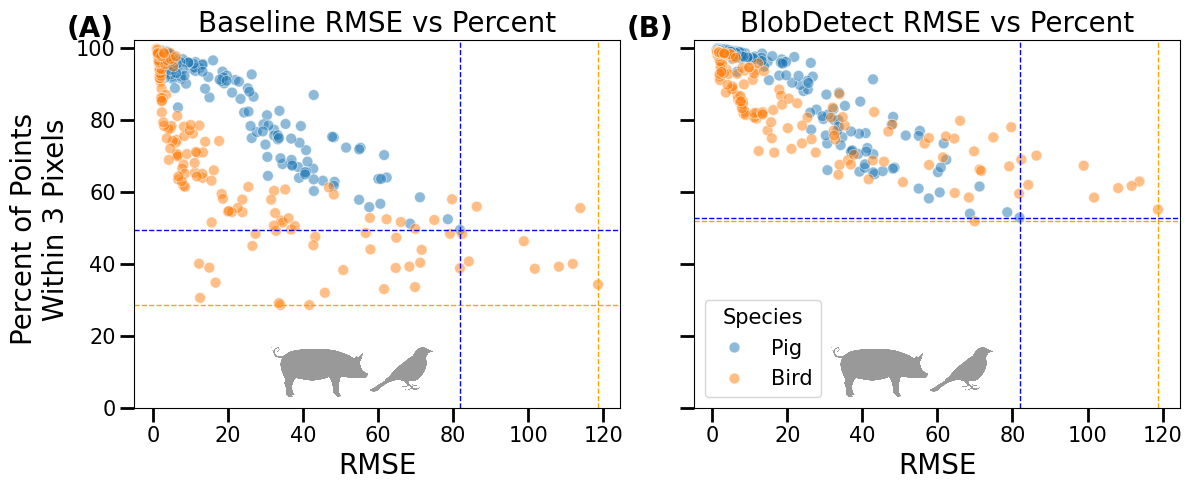

In [179]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plots = [
    (
        "rmse_px_baseline",
        "percent_points_within_threshold_baseline",
        "Baseline RMSE vs Percent",
    ),
    (
        "rmse_px_blobDetect",
        "percent_points_within_threshold_blobDetect",
        "BlobDetect RMSE vs Percent",
    ),
]
selectedmodelresults_complete["Animal"] = np.where(
    selectedmodelresults_complete["bird"] == "Pig",
    "Pig",
    "Bird"
)
selectedmodelresults_complete["train_trial"] = selectedmodelresults_complete["train_trial"].astype(str)
selectedmodelresults_complete["eval_trial"] = selectedmodelresults_complete["eval_trial"].astype(str)
i = 0
for ax, (xcol, ycol, title) in zip(axes, plots):


    sns.scatterplot(
        data=selectedmodelresults_complete,
        x=xcol,
        y=ycol,
        hue="Animal",      # optional
        # style = 'CombinedModel',
        alpha=0.5,
        s = 60,
        ax=ax
    )
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=15,  # tick number size
        length=10,     # tick mark length
        width=2        # tick mark thickness
    )
    # ax.axhline(selectedmodelresults_complete[selectedmodelresults_complete["CombinedModel"] == True][ycol].min(), color="orange", linestyle="--", lw=1)
    # ax.axvline(selectedmodelresults_complete[selectedmodelresults_complete["CombinedModel" ]== True][xcol].max(), color="orange", linestyle="--", lw=1)
    # ax.axhline(selectedmodelresults_complete[selectedmodelresults_complete["CombinedModel"] == False][ycol].min(), color="blue", linestyle="--", lw=1)
    # ax.axvline(selectedmodelresults_complete[selectedmodelresults_complete["CombinedModel" ]== False][xcol].max(), color="blue", linestyle="--", lw=1)
    ax.axhline(selectedmodelresults_complete[selectedmodelresults_complete["Animal"] == "Bird"][ycol].min(), color="orange", linestyle="--", lw=1)
    ax.axvline(selectedmodelresults_complete[selectedmodelresults_complete["Animal" ]== "Bird"][xcol].max(), color="orange", linestyle="--", lw=1)
    ax.axhline(selectedmodelresults_complete[selectedmodelresults_complete["Animal"] == "Pig"][ycol].min(), color="blue", linestyle="--", lw=1)
    ax.axvline(selectedmodelresults_complete[selectedmodelresults_complete["Animal" ]== "Pig"][xcol].max(), color="blue", linestyle="--", lw=1)
    ax.set_xlabel("RMSE", size=20)
    if i < 1:
        ax.set_ylabel("Percent of Points \n Within 3 Pixels",  size=20)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    ax.set_title(title,  size=20)
    ax.set_ylim(0, 102)
    i += 1
    # ax.set_aspect("equal", adjustable="box")
    
axes[0].get_legend().remove()

axes[1].legend(
    title="Species",
    loc="lower left",
    fontsize=15,
    title_fontsize=15
)
axes[0].text(
    -0.14, 1.07, "(A)",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)
axes[1].text(
    -0.14, 1.07, "(B)",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)

pig = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Pig_Silhouette.png").convert("RGBA")
bird = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png").convert("RGBA")
pig_img = OffsetImage(
    pig,
    zoom=0.09,
    alpha=0.4
)

pig_box = AnnotationBbox(
    pig_img,
    (0.38, 0.1),
    xycoords="axes fraction",
    frameon=False
)

axes[1].add_artist(pig_box)

bird_image = OffsetImage(
    bird,
    zoom=0.12,
    alpha=0.4
)

bird_box = AnnotationBbox(
    bird_image,
    (0.55, 0.1),
    xycoords="axes fraction",
    frameon=False
)

axes[1].add_artist(bird_box)
pig_box = AnnotationBbox(
    pig_img,
    (0.38, 0.1),
    xycoords="axes fraction",
    frameon=False
)

axes[0].add_artist(pig_box)

bird_box = AnnotationBbox(
    bird_image,
    (0.55, 0.1),
    xycoords="axes fraction",
    frameon=False
)

axes[0].add_artist(bird_box)

plt.tight_layout()
plt.savefig(r"/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/ModelPreformance_Blobdetect_Figure.png", dpi=300, bbox_inches="tight", )
plt.show()


/tmp/ipykernel_148050/627944004.py:27: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


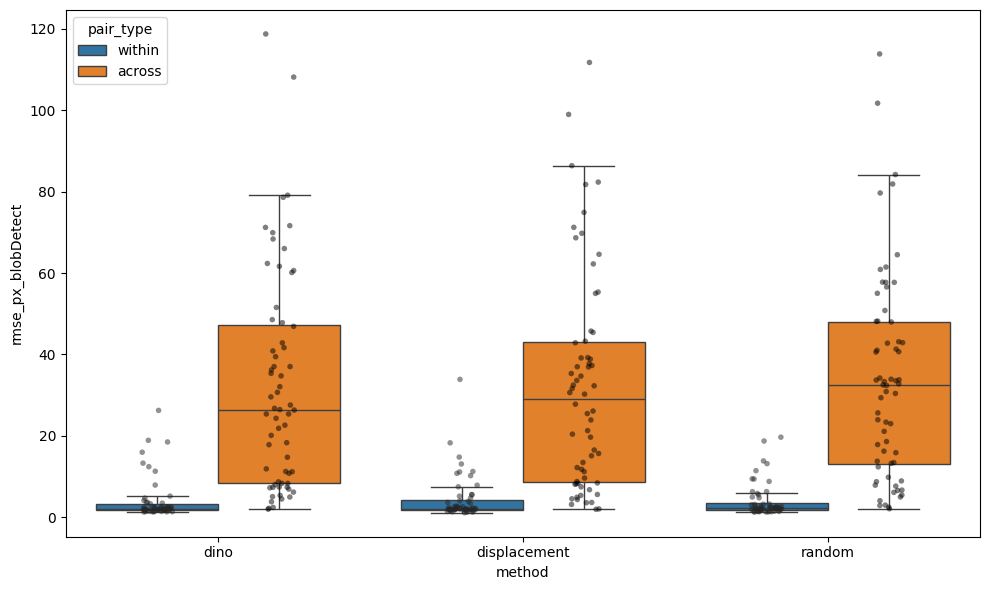

/tmp/ipykernel_148050/627944004.py:60: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


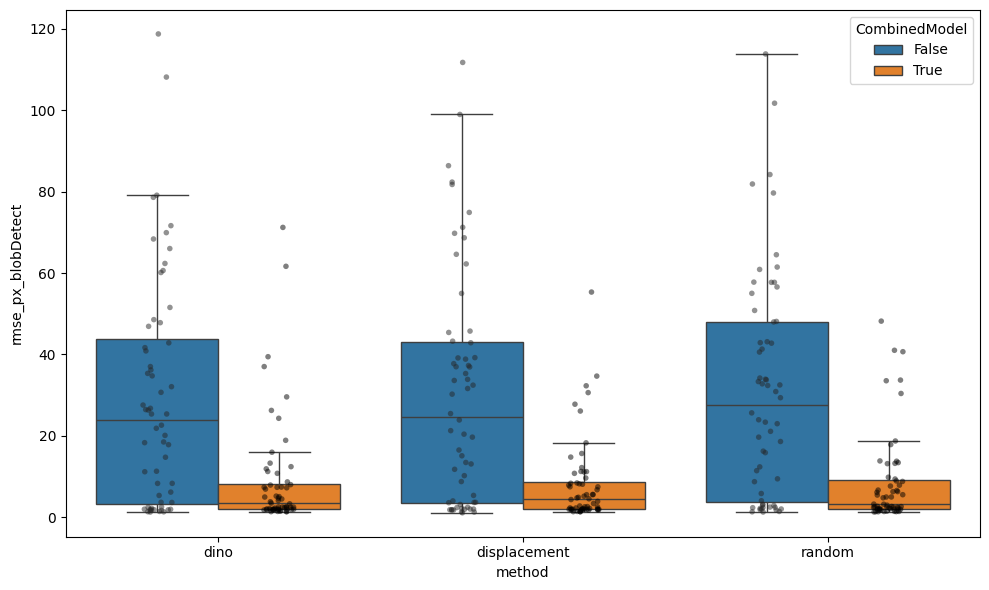

In [98]:


plot_df = selectedmodelresults_complete.copy()
long_df = pd.concat([
    plot_df.assign(
        Detector="Baseline",
        RMSE=plot_df["rmse_px_baseline"],
    ),
    plot_df.assign(
        Detector="BlobDetect",
        RMSE=plot_df["rmse_px_blobDetect"],
    ),
], ignore_index=True)


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="pair_type",
    ax=ax,
    showfliers=False,   # optional
)


# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="pair_type",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="CombinedModel",
    ax=ax,
    showfliers=False,   # optional
)


# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="CombinedModel",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="CombinedModel")

plt.tight_layout()
plt.show()



In [99]:
plot_df 

,Unnamed: 0,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,...,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type,CombinedModel,Animal
0,0,Pig,1,1,dino,50,3.670955,3.617743,-0.053212,98.066667,...,22.000000,19.613333,19.893333,1.400000,20,98.066667,99.466667,within,False,Pig
1,36,Pig,4,1,dino,50,48.354243,48.554452,0.200208,62.716667,...,7.333333,12.543333,13.330000,3.933333,20,62.716667,66.650000,across,False,Pig
2,72,Pig,6,1,dino,50,21.860326,21.851076,-0.009250,90.983333,...,59.666667,18.196667,19.476667,6.400000,20,90.983333,97.383333,across,False,Pig
3,108,Pig,41,1,dino,50,1.904320,1.792996,-0.111324,97.100000,...,34.333333,19.420000,19.890000,2.350000,20,97.100000,99.450000,within,True,Pig
4,144,Pig,46,1,dino,50,7.484299,7.344179,-0.140120,91.350000,...,60.333333,18.270000,19.703333,7.166667,20,91.350000,98.516667,across,True,Pig
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,343,DavidBowie,16,17,random,100,57.786060,57.722005,-0.064055,52.682540,...,0.000000,22.126667,31.446667,22.190476,42,52.682540,74.873016,across,False,Bird
356,344,DavidBowie,17,17,random,100,2.787722,3.138638,0.350916,98.690476,...,-27.333333,41.450000,41.270000,-0.428571,42,98.690476,98.261905,within,False,Bird
357,345,DavidBowie,1516,17,random,100,9.999229,9.819129,-0.180100,78.492063,...,19.000000,32.966667,39.690000,16.007937,42,78.492063,94.500000,across,True,Bird
358,346,DavidBowie,1517,17,random,100,6.090610,6.284707,0.194097,97.563492,...,-20.000000,40.976667,40.810000,-0.396825,42,97.563492,97.166667,within,True,Bird


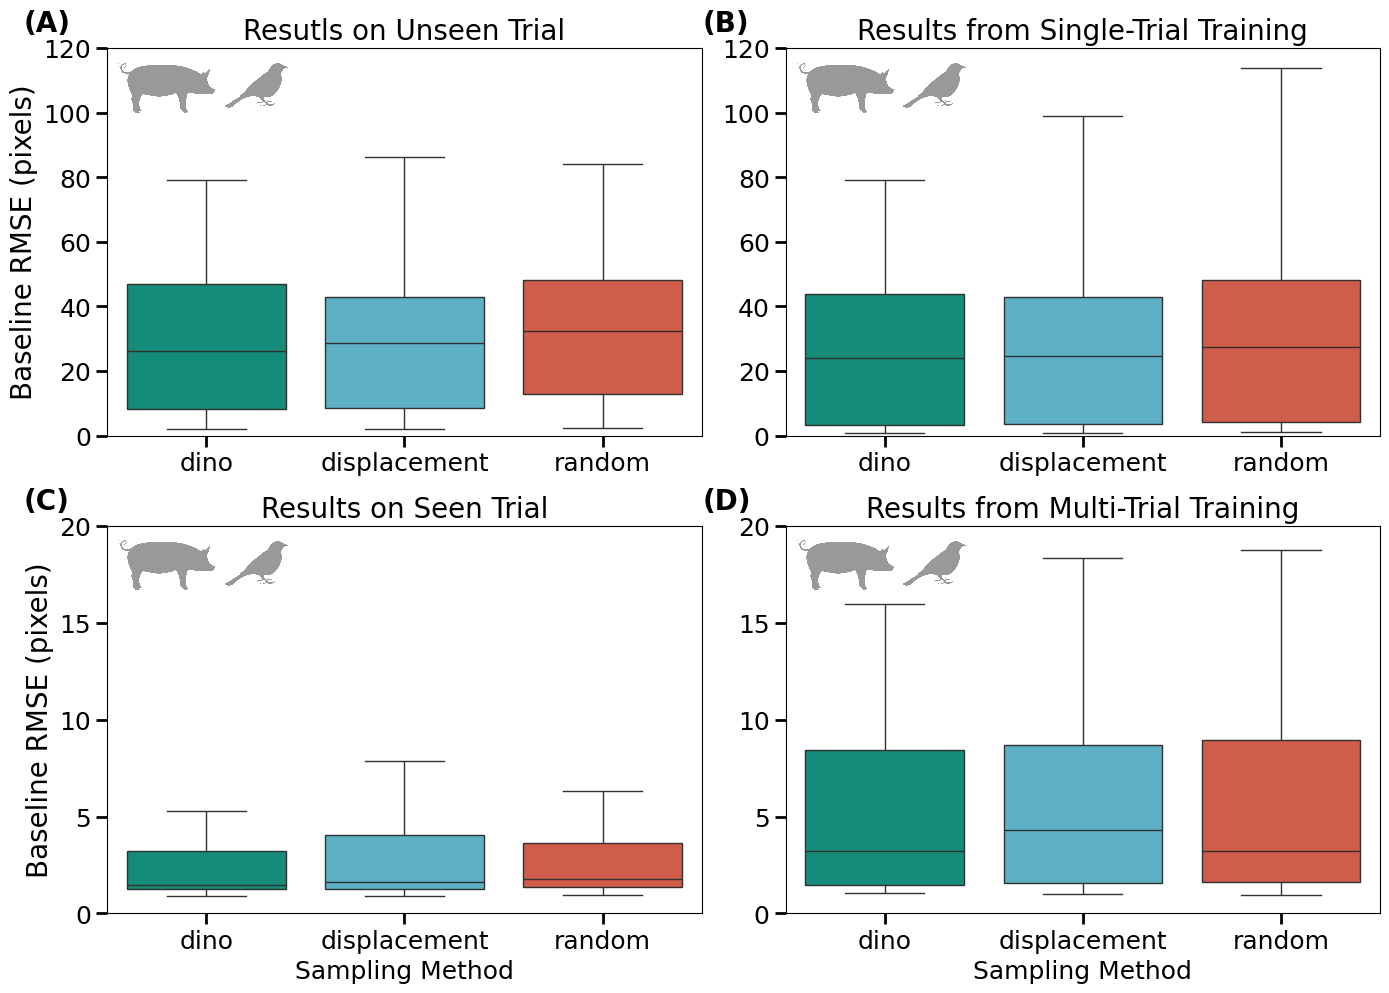

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = selectedmodelresults_complete.copy()

model_palette = {
    "random": "#E64B35",
    "displacement": "#4DBBD5",
    "dino": "#00A087",
}

# Convert CombinedModel to labels
plot_df["CombinedModel"] = plot_df["CombinedModel"].map({
    True: "Combined",
    False: "Not Combined"
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=False
)

# --------------------------------------------------
# 1. Across
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["pair_type"] == "across"],
    x="method",
    y="rmse_px_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[0, 0]
)


axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Baseline RMSE (pixels)", fontsize=20)
axes[0, 0].set_ylim(0, 120)


# --------------------------------------------------
# 2. Within
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["pair_type"] == "within"],
    x="method",
    y="rmse_px_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[1, 0]
)


axes[1, 0].set_xlabel("Sampling Method", fontsize=18)
# axes[1, 0].set_ylabel("")
axes[1, 0].set_ylabel("Baseline RMSE (pixels)", fontsize=20)
axes[1, 0].set_ylim(ymin = 0, ymax = 20)
# --------------------------------------------------
# 3. Combined
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["CombinedModel"] == "Combined"],
    x="method",
    y="rmse_px_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[1, 1]
)

axes[1, 1].set_xlabel("Sampling Method", fontsize=18)
# axes[1, 1].set_ylabel("Baseline RMSE (pixels)", fontsize=14)
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(ymin = 0, ymax = 20)

# --------------------------------------------------
# 4. Not Combined
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["CombinedModel"] == "Not Combined"],
    x="method",
    y="rmse_px_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[0, 1]
)


axes[0, 1].set_xlabel("", fontsize=14)
axes[0, 1].set_ylabel("")
axes[0, 1].set_ylim(0, 120)

axes[0, 0].set_title("Resutls on Unseen Trial", fontsize=20)
axes[0, 1].set_title("Results from Single-Trial Training", fontsize=20)
axes[1, 0].set_title("Results on Seen Trial", fontsize=20)
axes[1, 1].set_title("Results from Multi-Trial Training", fontsize=20)
pig = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Pig_Silhouette.png").convert("RGBA")
bird = Image.open("/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png").convert("RGBA")


axes[0,0].text(
    -0.14, 1.1, "(A)",
    transform=axes[0,0].transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)
axes[0,1].text(
    -0.14, 1.1, "(B)",
    transform=axes[0,1].transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)
axes[1,0].text(
    -0.14, 1.1, "(C)",
    transform=axes[1,0].transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)
axes[1,1].text(
    -0.14, 1.1, "(D)",
    transform=axes[1,1].transAxes,
    ha="left",
    va="top",
    fontsize=20,
    fontweight="bold"
)

add_silhouette(
    axes[0, 0],
    pig,
    position=(0.1, 0.9),
    zoom=0.09,
    alpha=0.4
)

add_silhouette(
    axes[1, 0],
    pig,
    position=(0.1, 0.9),
    zoom=0.09,
    alpha=0.4
)

add_silhouette(
    axes[1, 1],
    pig,
    position=(0.1, 0.9),
    zoom=0.09,
    alpha=0.4
)

add_silhouette(
    axes[0, 1],
    pig,
    position=(0.1, 0.9),
    zoom=0.09,
    alpha=0.4
)


# Bird panels
add_silhouette(
    axes[0, 1],
    bird,
    position=(0.25, 0.9),
    zoom=0.12,
    alpha=0.4
)

add_silhouette(
    axes[1, 1],
    bird,
    position=(0.25, 0.9),
    zoom=0.12,
    alpha=0.4
)

# Bird panels
add_silhouette(
    axes[1, 0],
    bird,
    position=(0.25, 0.9),
    zoom=0.12,
    alpha=0.4
)

add_silhouette(
    axes[0,0],
    bird,
    position=(0.25, 0.9),
    zoom=0.12,
    alpha=0.4
)

for ax in axes.flat:
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=18,
        length=8,
        width=2
    )
# --------------------------------------------------
# Formatting
# --------------------------------------------------
plt.savefig('/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/ModelSelectionRMSEComp_Figure.png', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

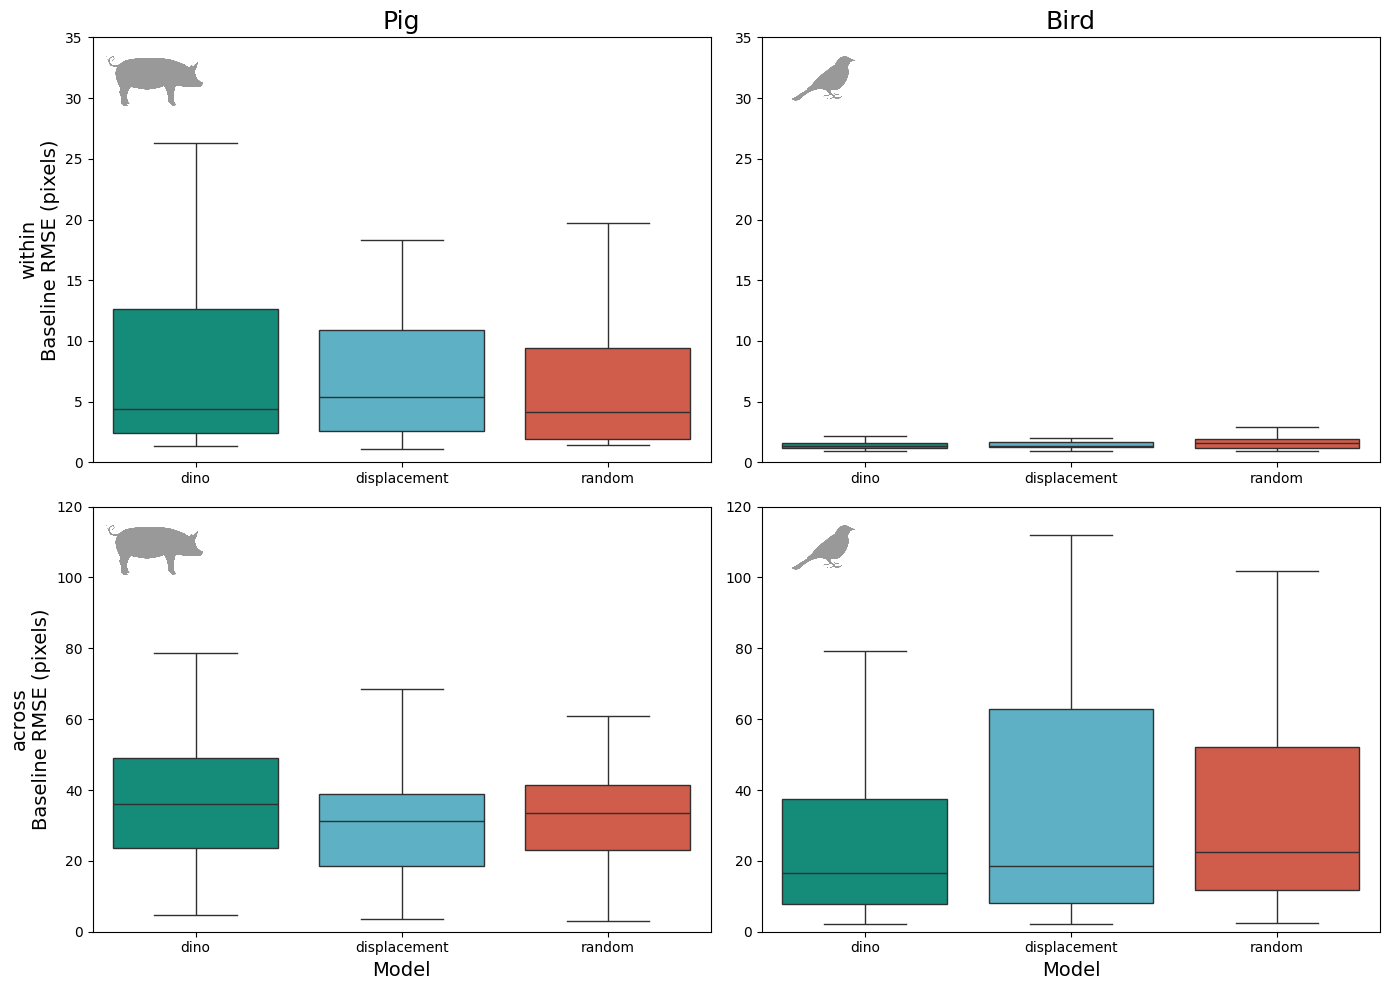

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

plot_df = selectedmodelresults_complete.copy()

model_palette = {
    "random": "#E64B35",
    "displacement": "#4DBBD5",
    "dino": "#00A087",
}

# --------------------------------------------------
# Figure layout
# Columns = Animal
# Rows = pair_type
# --------------------------------------------------



fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=False
)

# --------------------------------------------------
# Load silhouettes
# --------------------------------------------------

pig = Image.open(
    "/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Pig_Silhouette.png"
).convert("RGBA")

bird = Image.open(
    "/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/Bird_Silhouette.png"
).convert("RGBA")


# --------------------------------------------------
# Plot each Animal × pair_type combination
# --------------------------------------------------

for row, pair_type in enumerate(plot_df['pair_type'].unique()):
    for col, animal in enumerate(plot_df['Animal'].unique()):

        ax = axes[row, col]

        subset = plot_df[
            (plot_df["Animal"] == animal) &
            (plot_df["pair_type"] == pair_type)
        ]

        sns.boxplot(
            data=subset,
            x="method",
            y="rmse_px_baseline",
            hue="method",
            palette=model_palette,
            legend=False,
            showfliers=False,
            ax=ax
        )

        # ------------------------------------------
        # Titles
        # ------------------------------------------

        if row == 0:
            ax.set_title(animal, fontsize=18)

        if col == 0:
            ax.set_ylabel(
                f"{pair_type}\nBaseline RMSE (pixels)",
                fontsize=14
            )
        else:
            ax.set_ylabel("")

        # ------------------------------------------
        # X-axis
        # ------------------------------------------

        if row == 1:
            ax.set_xlabel("Model", fontsize=14)
        else:
            ax.set_xlabel("")

        # ------------------------------------------
        # Y limits
        # ------------------------------------------

        if pair_type == "across":
            ax.set_ylim(0, 120)
        else:
            ax.set_ylim(0, 35)

        # ------------------------------------------
        # Silhouette
        # ------------------------------------------

        if animal == "Pig":
            add_silhouette(
                ax,
                pig,
                position=(0.1, 0.9),
                zoom=0.09,
                alpha=0.4
            )

        elif animal == "Bird":
            add_silhouette(
                ax,
                bird,
                position=(0.1, 0.9),
                zoom=0.12,
                alpha=0.4
            )


# --------------------------------------------------
# Formatting
# --------------------------------------------------

plt.tight_layout()

# plt.savefig(
#     "/home/kelsey/Documents/TylerMachineLearning/Testing/"
#     "DeepLabCutExperiments/Figures/ModelSelectionRMSEComp_Figure.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

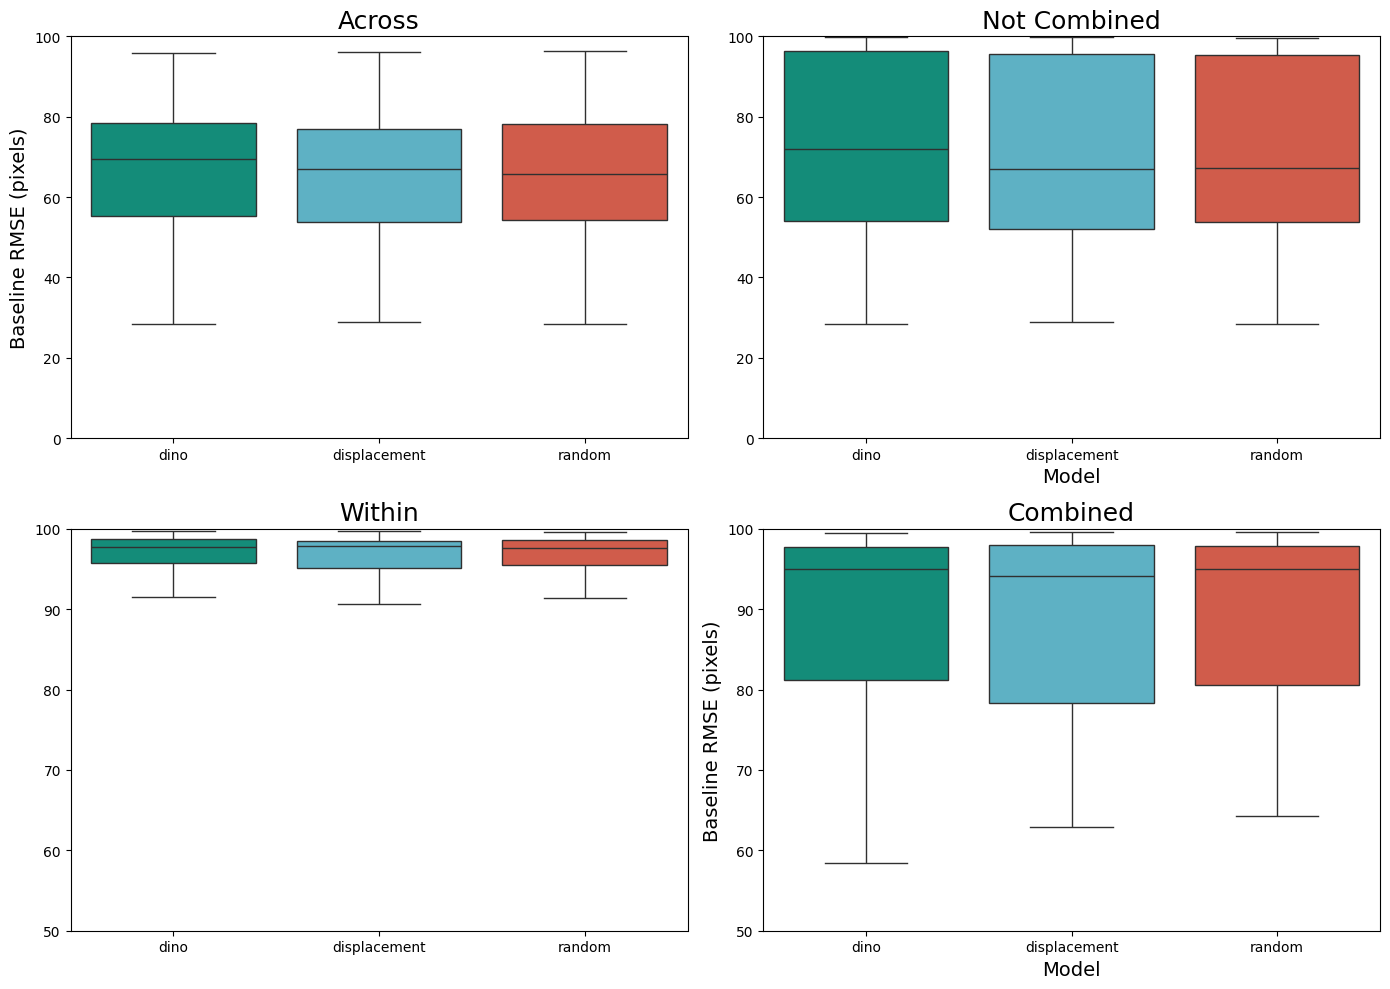

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = selectedmodelresults_complete.copy()

model_palette = {
    "random": "#E64B35",
    "displacement": "#4DBBD5",
    "dino": "#00A087",
}

# Convert CombinedModel to labels
plot_df["CombinedModel"] = plot_df["CombinedModel"].map({
    True: "Combined",
    False: "Not Combined"
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    sharey=False
)

# --------------------------------------------------
# 1. Across
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["pair_type"] == "across"],
    x="method",
    y="percent_points_within_threshold_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Across", fontsize=18)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Baseline RMSE (pixels)", fontsize=14)
axes[0, 0].set_ylim(0,100)


# --------------------------------------------------
# 2. Within
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["pair_type"] == "within"],
    x="method",
    y="percent_points_within_threshold_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Within", fontsize=18)
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("")
axes[1, 0].set_ylim(50,100)
# --------------------------------------------------
# 3. Combined
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["CombinedModel"] == "Combined"],
    x="method",
    y="percent_points_within_threshold_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Combined", fontsize=18)
axes[1, 1].set_xlabel("Model", fontsize=14)
axes[1, 1].set_ylabel("Baseline RMSE (pixels)", fontsize=14)
axes[1, 1].set_ylim(50,100)

# --------------------------------------------------
# 4. Not Combined
# --------------------------------------------------
sns.boxplot(
    data=plot_df[plot_df["CombinedModel"] == "Not Combined"],
    x="method",
    y="percent_points_within_threshold_baseline",
    hue="method",
    palette=model_palette,
    legend=False,
    showfliers=False,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Not Combined", fontsize=18)
axes[0, 1].set_xlabel("Model", fontsize=14)
axes[0, 1].set_ylabel("")
axes[0, 1].set_ylim(0, 100)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
plt.savefig('/home/kelsey/Documents/TylerMachineLearning/Testing/DeepLabCutExperiments/Figures/ModelSelectionPP3Comp_Figure.png', dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

CombinedModel  method  index  Combined  Not Combined
0                dino      0  0.000000      3.670955
1                dino      1  0.000000     48.354243
2                dino      2  0.000000     21.860326
3                dino      3  1.904320      0.000000
4                dino      4  7.484299      0.000000
..                ...    ...       ...           ...
355            random    355  0.000000     57.786060
356            random    356  0.000000      2.787722
357            random    357  9.999229      0.000000
358            random    358  6.090610      0.000000
359            random    359  2.909065      0.000000

[360 rows x 4 columns]


<Figure size 1600x700 with 0 Axes>

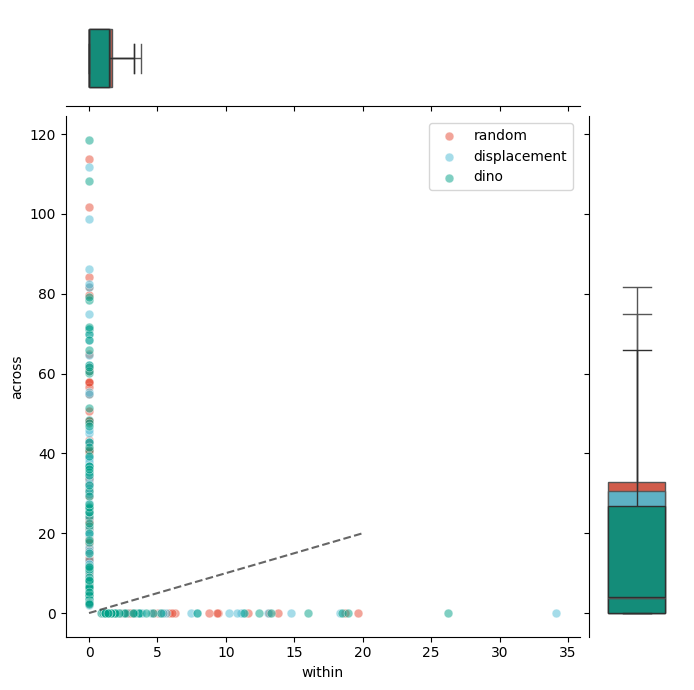

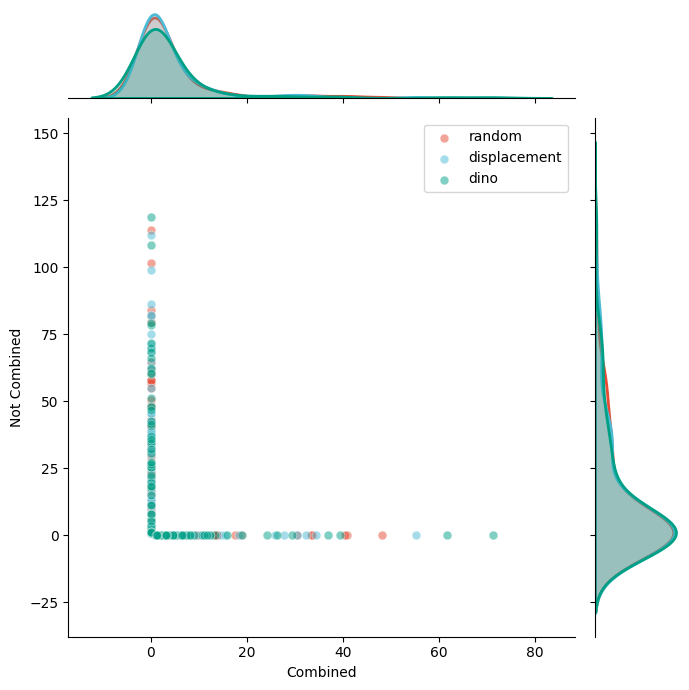

In [171]:


plot_df = selectedmodelresults_complete.copy()
model_palette = {  
    "random": "#E64B35",
    "displacement": "#4DBBD5",
    "dino": "#00A087",
}


plot_df['index'] = plot_df.index
within_across = (
    plot_df
    .pivot_table(
        index=["method", 'index'],
        columns="pair_type",
        values="rmse_px_baseline"
    )
    .reset_index()
)
within_across.fillna(0, inplace=True)

plot_df['CombinedModel'] = ['Combined' if x else 'Not Combined' for x in plot_df['CombinedModel']]
combined_not = (
    plot_df
    .pivot_table(
        index=["method", 'index'],
        columns="CombinedModel",
        values="rmse_px_baseline"
    )
    .reset_index()
)
combined_not.fillna(0, inplace=True)
print(combined_not)

# combined_not = combined_not.dropna(
#     subset=["True", "False"]
# )
fig = plt.figure(figsize=(16, 7))

# ==========================================
# Within vs Across
# ==========================================

g1 = sns.JointGrid(
    data=within_across,
    x="within",
    y="across",
    height=7,
    ratio=5,
    space=0.1
)

for model, color in model_palette.items():

    subset = within_across[
        within_across["method"] == model
    ]

    # Joint distribution
    sns.scatterplot(
        data=subset,
        x="within",
        y="across",
        color=color,
        alpha=0.5,
        s=40,
        ax=g1.ax_joint,
        label=model
    )
        # -------------------------
    # Top: Within boxplot
    # -------------------------
    sns.boxplot(
        x=subset["within"],
        color=color,
        width=0.6,
        fliersize=0,
        ax=g1.ax_marg_x
    )

    # -------------------------
    # Right: Across boxplot
    # -------------------------
    sns.boxplot(
        y=subset["across"],
        color=color,
        width=0.6,
        fliersize=0,
        ax=g1.ax_marg_y
    )

g1.ax_joint.plot(
    [0, 20],
    [0, 20],
    "--",
    color="black",
    alpha=0.6
)


# ==========================================
# Combined vs Not Combined
# ==========================================

g2 = sns.JointGrid(
    data=combined_not,
    x="Combined",
    y='Not Combined',
    height=7,
    ratio=5,
    space=0.1
)

for model, color in model_palette.items():

    subset = combined_not[
        combined_not["method"] == model
    ]

    sns.scatterplot(
        data=subset,
        x="Combined",
        y="Not Combined",
        color=color,
        alpha=0.5,
        s=40,
        ax=g2.ax_joint,
        label=model
    )
      # Top KDE: Within distribution
    sns.kdeplot(
        data=subset,
        x="Combined",
        color=color,
        fill=True,
        alpha=0.25,
        linewidth=2,
        ax=g2.ax_marg_x
    )

    # Right KDE: Across distribution
    sns.kdeplot(
        data=subset,
        y="Not Combined",
        color=color,
        fill=True,
        alpha=0.25,
        linewidth=2,
        ax=g2.ax_marg_y
    )
plt.tight_layout()
plt.show()